In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ── Define stock universe ──────────────────────────────────────────────────────
tickers = {
    'RELIANCE': 'RELIANCE.NS',
    'HDFCBANK': 'HDFCBANK.NS',
    'INFY':     'INFY.NS',
    'SUNPHARMA':'SUNPHARMA.NS',
    'MARUTI':   'MARUTI.NS',
    'ITC':      'ITC.NS',
    'TATASTEEL':'TATASTEEL.NS'
}

# ── Fetch all data ─────────────────────────────────────────────────────────────
raw_data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2021-01-01", end="2025-12-31", interval="1d", auto_adjust=True)
    raw_data[name] = df
    print(f"{name}: {len(df)} rows fetched")

[*********************100%***********************]  1 of 1 completed


RELIANCE: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed


HDFCBANK: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed


...

MARUTI: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed


ITC: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed

TATASTEEL: 1235 rows fetched


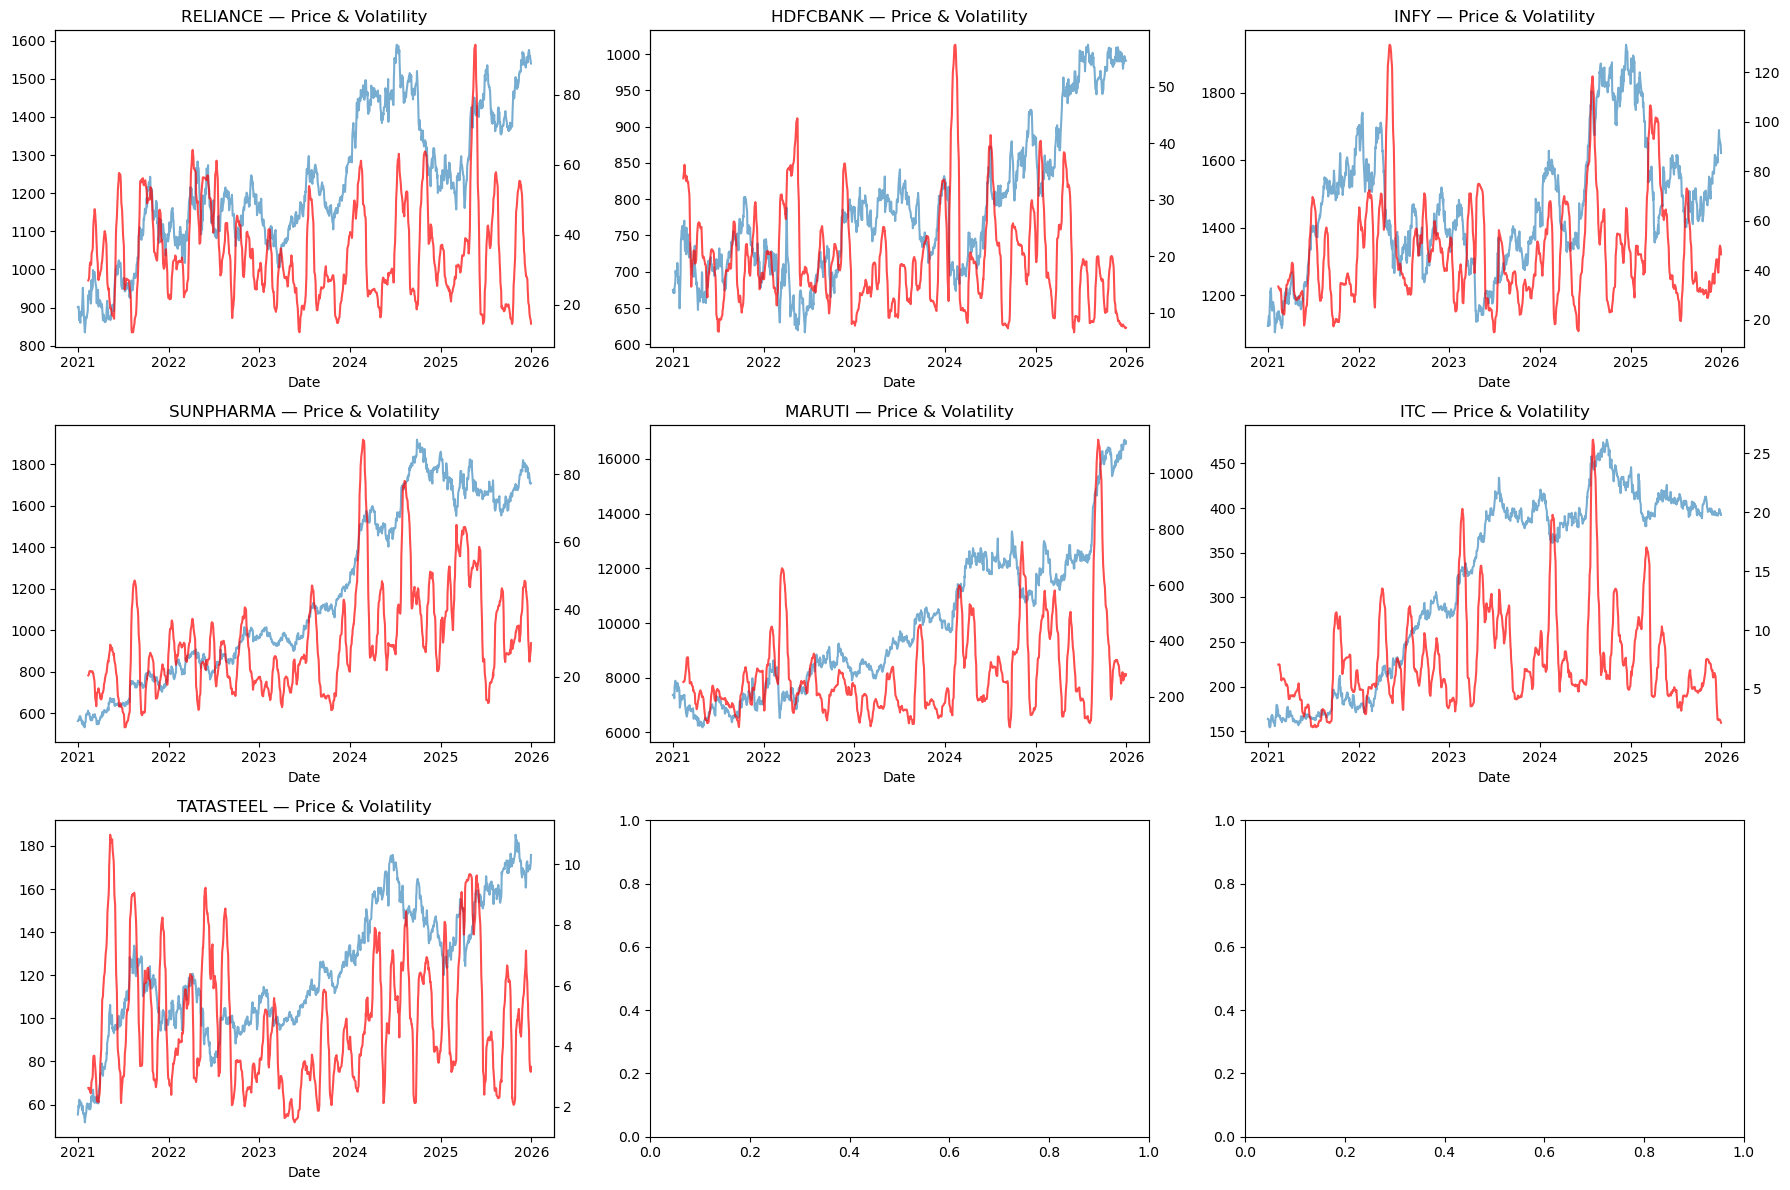

In [3]:
# ── Justification 1: Rolling Standard Deviation (Volatility Profiles) ─────────
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(raw_data.items()):
    close = df['Close'].squeeze()
    rolling_std = close.rolling(window=30).std()
    axes[idx].plot(close, label='Close Price', alpha=0.6)
    ax2 = axes[idx].twinx()
    ax2.plot(rolling_std, color='red', label='30-day Rolling Std', alpha=0.7)
    axes[idx].set_title(f'{name} — Price & Volatility')
    axes[idx].set_xlabel('Date')

plt.tight_layout()
plt.savefig('task1_rolling_std.png', dpi=150)
plt.show()

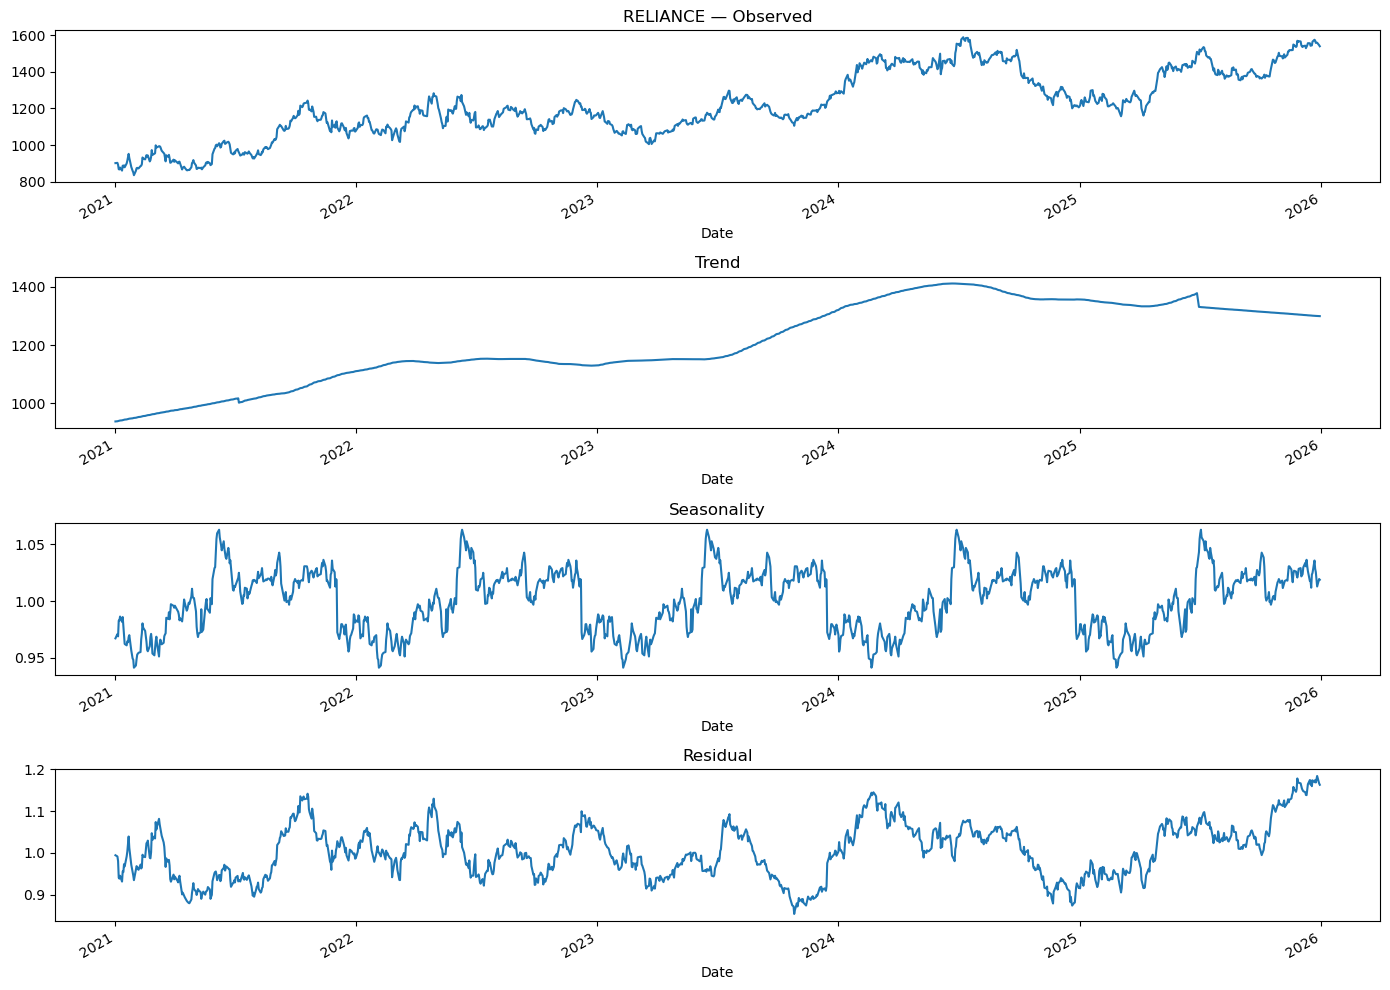

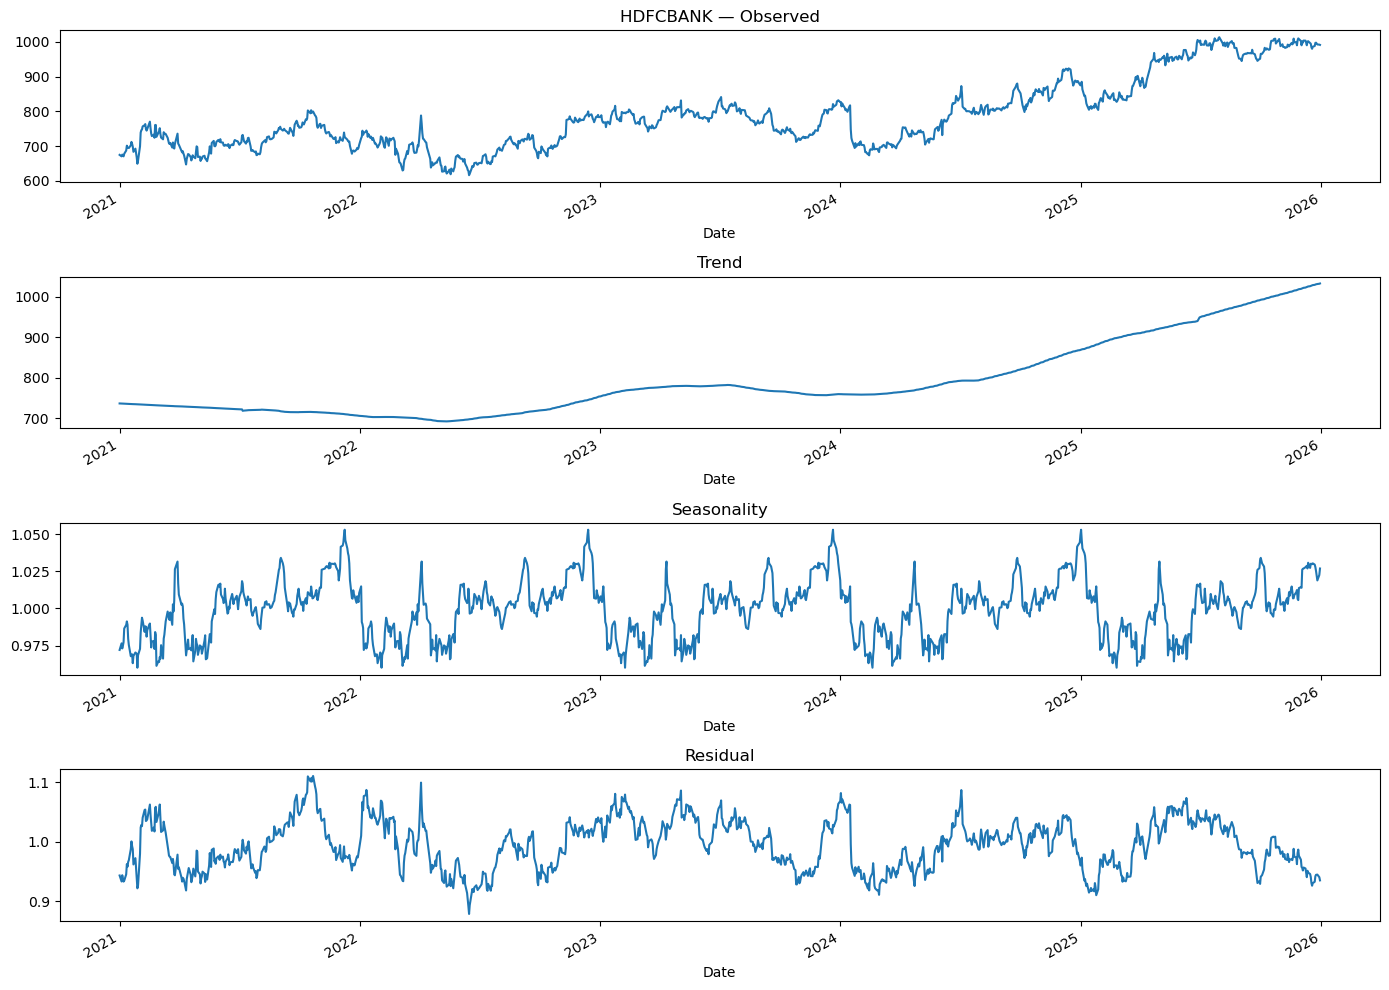

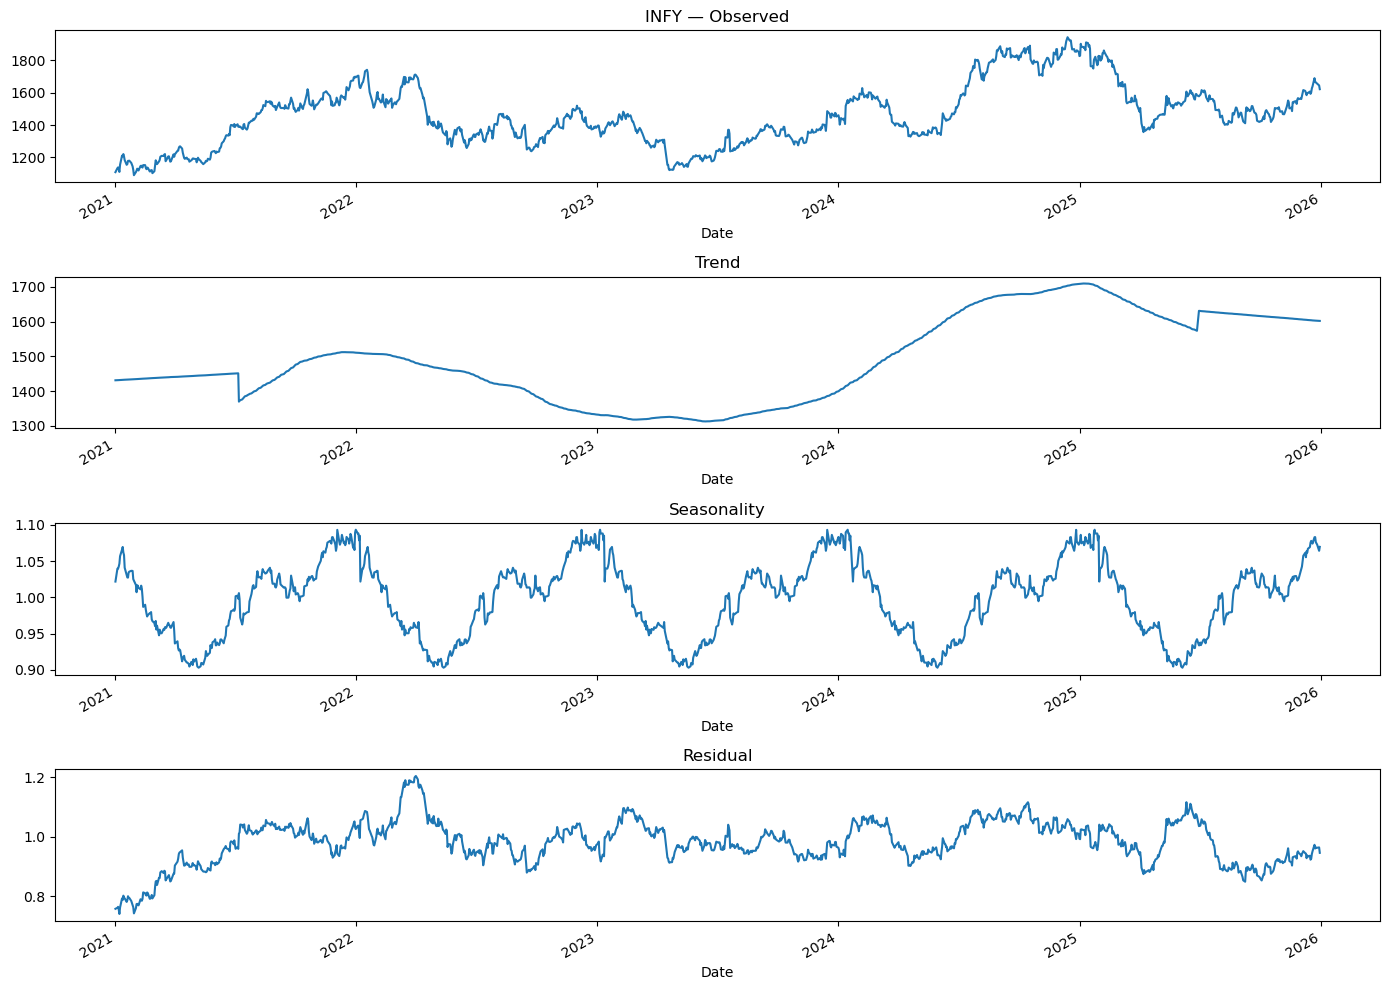

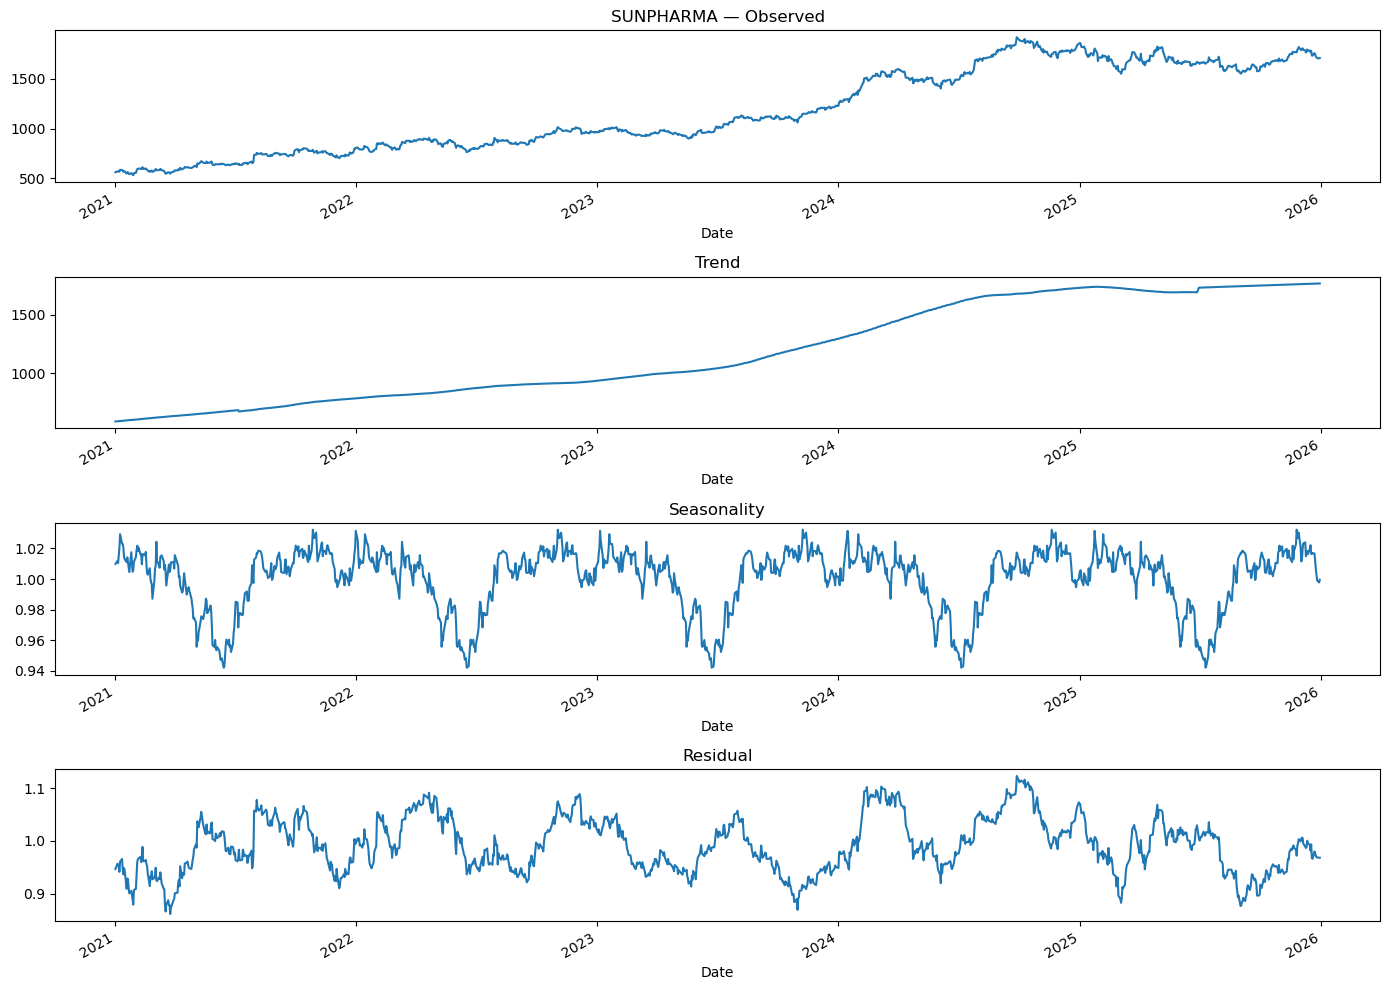

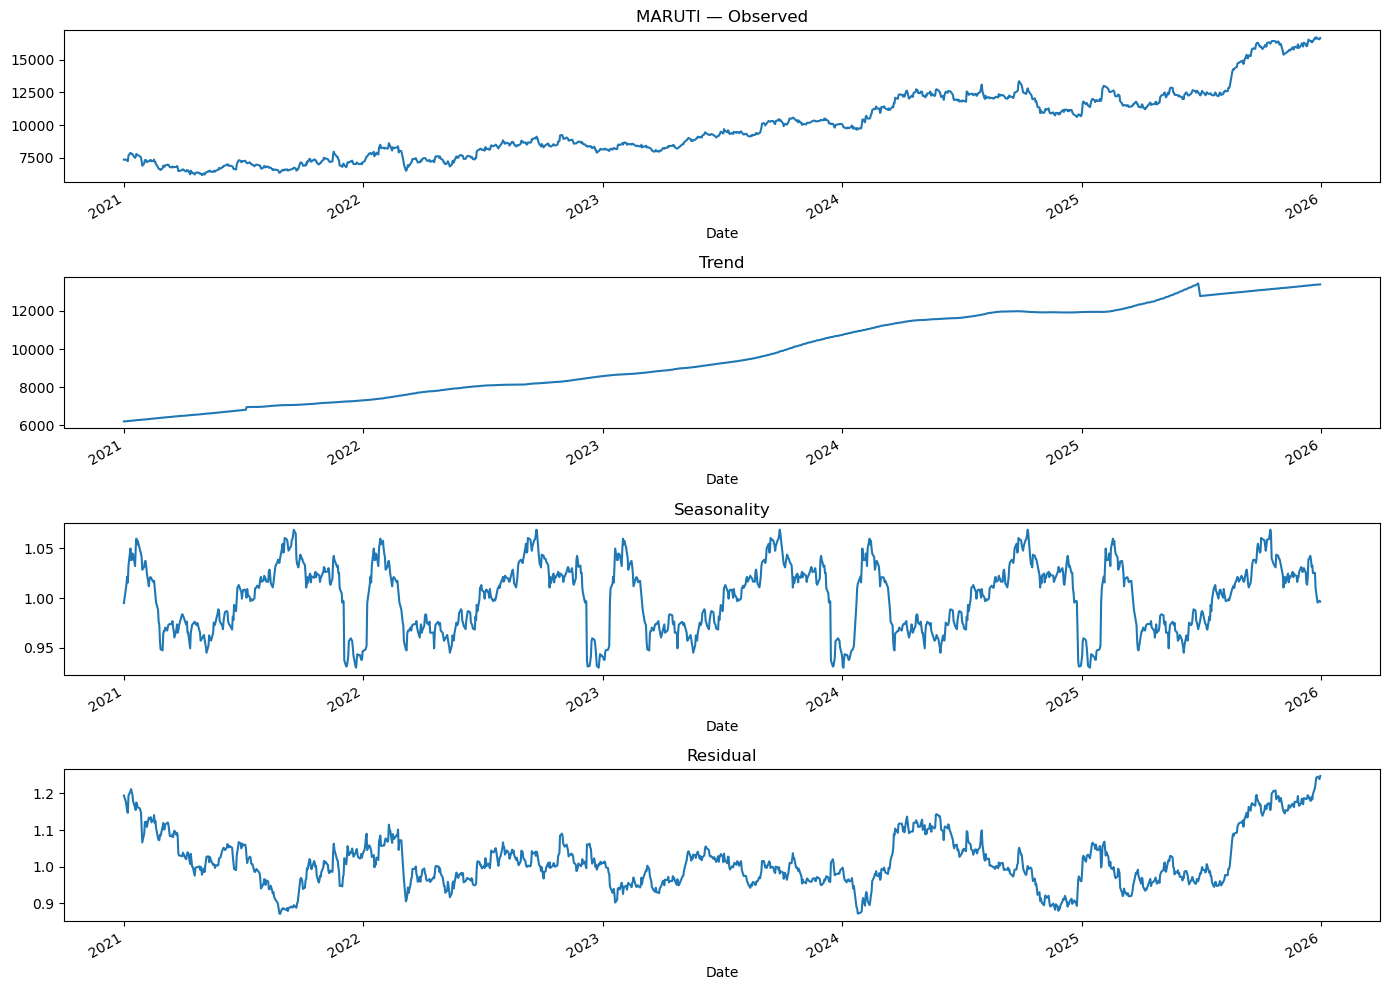

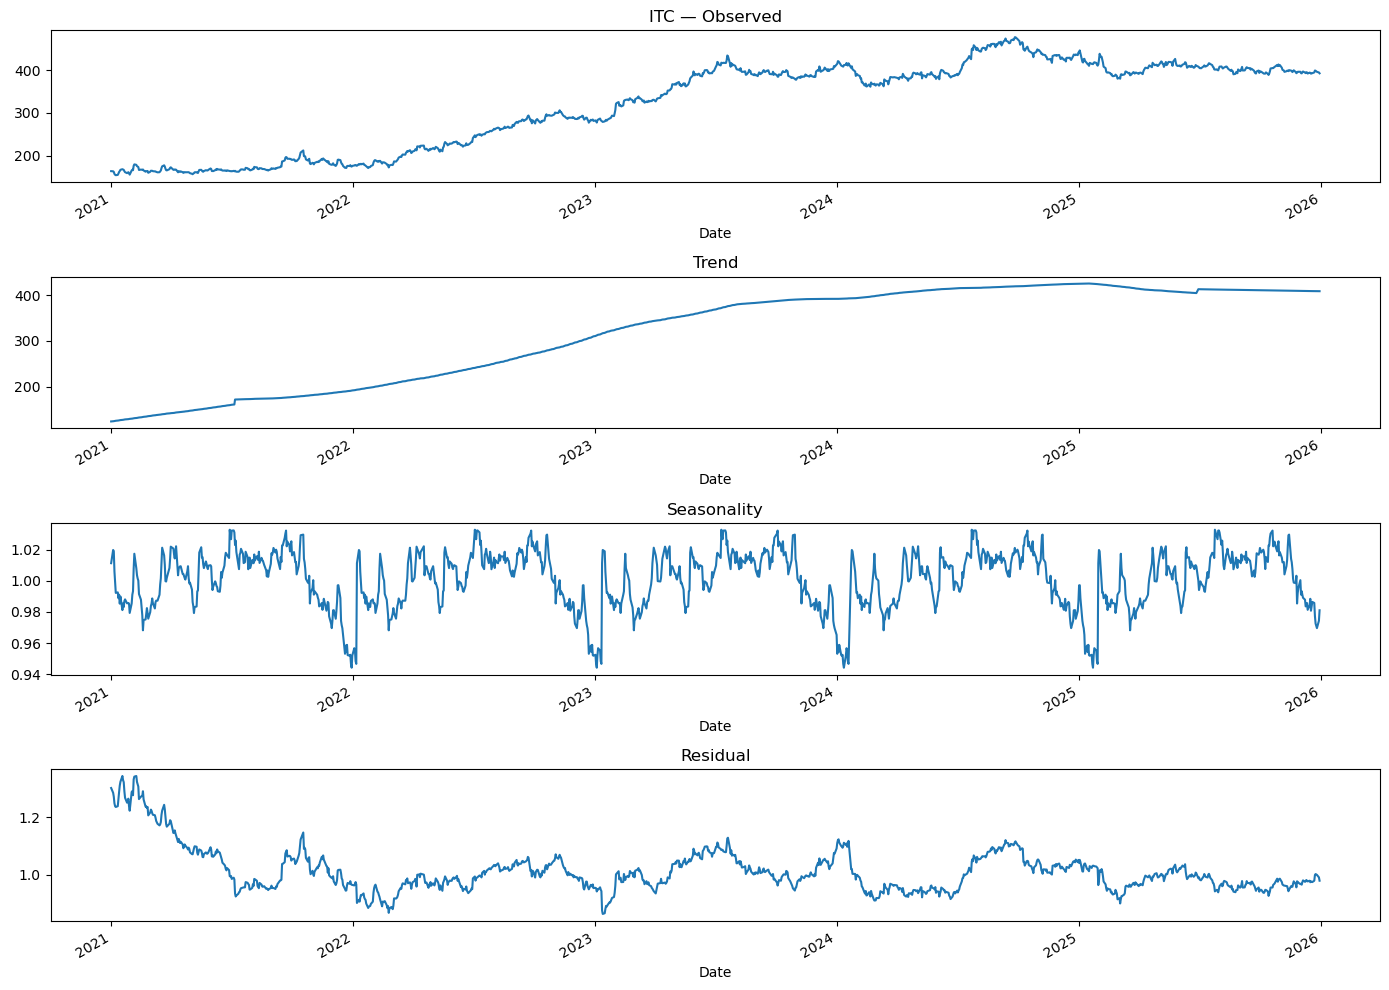

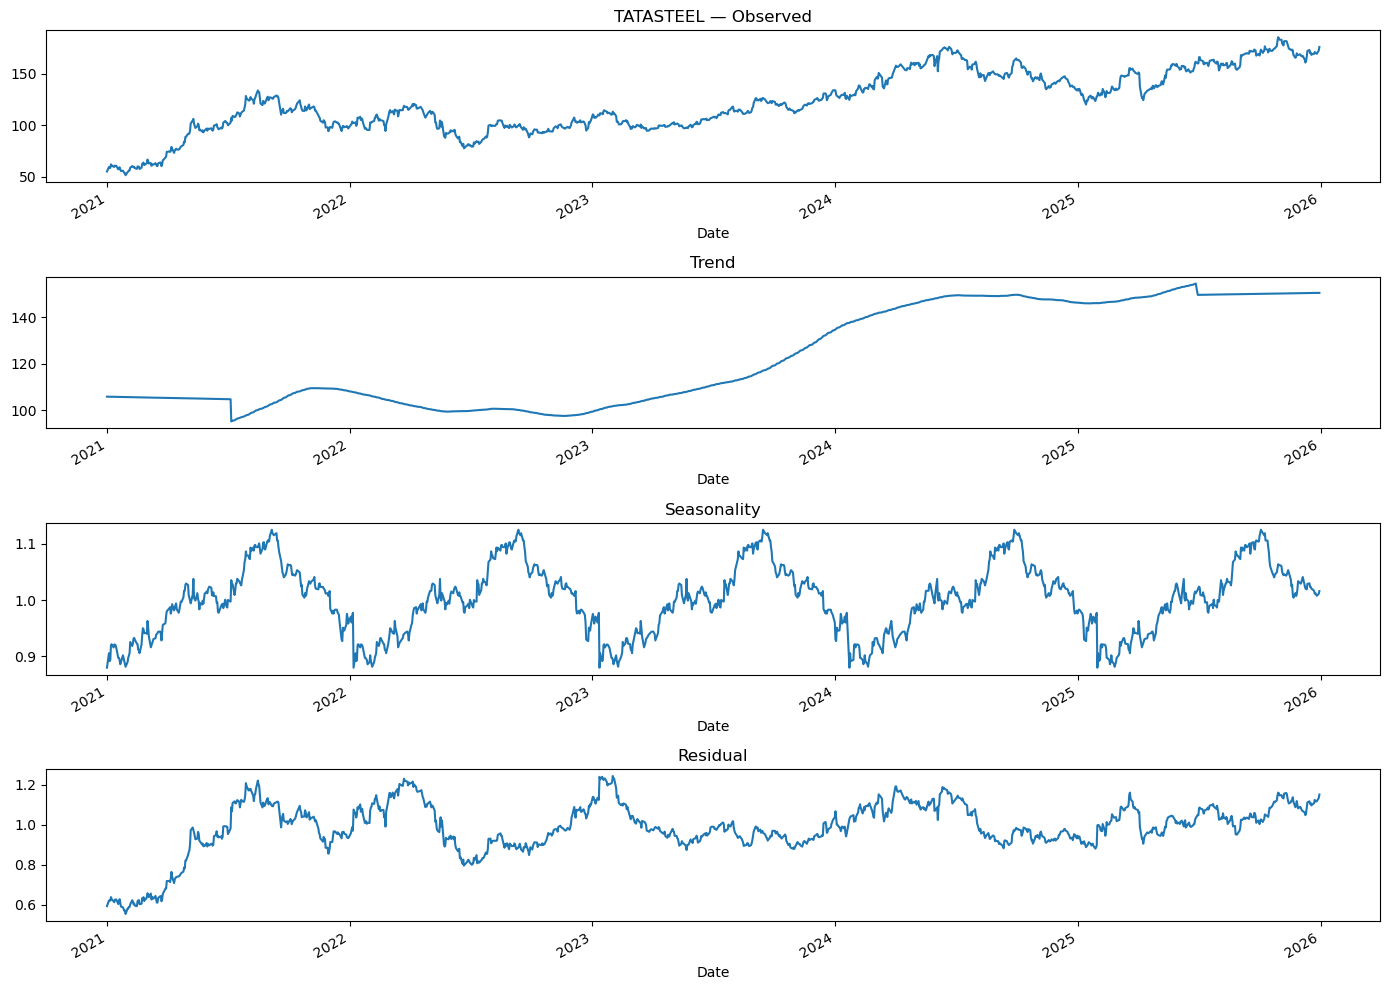

In [4]:
# ── Justification 2: Seasonal Decomposition (Trend Strength) ──────────────────
for name, df in raw_data.items():
    close = df['Close'].squeeze().dropna()
    # Need at least 2 full periods; use period=252 (trading days/year)
    decomp = seasonal_decompose(close, model='multiplicative', period=252, extrapolate_trend='freq')
    
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10))
    decomp.observed.plot(ax=ax1, title=f'{name} — Observed')
    decomp.trend.plot(ax=ax2, title='Trend')
    decomp.seasonal.plot(ax=ax3, title='Seasonality')
    decomp.resid.plot(ax=ax4, title='Residual')
    plt.tight_layout()
    plt.savefig(f'task1_decomp_{name}.png', dpi=100)
    plt.show()

-> RELIANCE: Strong upward trend; moderate volatility → strong trend candidate
-> HDFCBANK: Banking sector momentum; lower volatility → stable allocation
-> INFY: IT sector; high rolling std in 2022–2023 → interesting volatility profile
-> SUNPHARMA: Defensive sector; low correlation with cyclicals
-> MARUTI: Auto recovery cycle visible in trend decomposition
-> ITC: FMCG; consistent upward trend post-2022; low seasonal noise
-> TATASTEEL: High volatility, cyclical → diversification through metals

In [5]:
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler

# ── Step 1: Extract Close prices into a single DataFrame ──────────────────────
close_prices = pd.DataFrame({
    name: df['Close'].squeeze() for name, df in raw_data.items()
})
print("Shape before cleaning:", close_prices.shape)
print("Missing values:\n", close_prices.isnull().sum())

# ── Step 2: Handle missing values ─────────────────────────────────────────────
# Forward fill first, then backward fill for any leading NaNs
close_prices = close_prices.ffill().bfill()
print("Missing after fill:", close_prices.isnull().sum().sum())

# ── Step 3: ADF Stationarity Test ─────────────────────────────────────────────
def adf_test(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = p_value < 0.05
    print(f"{name:12s} | ADF Stat: {result[0]:8.4f} | p-value: {p_value:.4f} | "
          f"Stationary: {'YES' if is_stationary else 'NO'}")
    return is_stationary

print("=" * 65)
print("ADF Test on Raw Price Series:")
print("=" * 65)
stationarity = {}
for col in close_prices.columns:
    stationarity[col] = adf_test(close_prices[col], col)

# ── Step 4: Apply differencing for non-stationary series ──────────────────────
# (Almost all raw stock price series will be non-stationary)
returns = close_prices.pct_change().dropna()  # Log returns also acceptable
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

print("\nADF Test on Log Returns (differenced):")
print("=" * 65)
for col in log_returns.columns:
    adf_test(log_returns[col], col)

# ── Step 5: Train / Test Split ────────────────────────────────────────────────
# Training: Jan 2021 – Jun 2025
# Testing:  Jul 2025 – Dec 2025

train_end   = '2025-06-30'
test_start  = '2025-07-01'

train_prices = close_prices.loc[:train_end]
test_prices  = close_prices.loc[test_start:]

print(f"Training set: {train_prices.index[0].date()} → {train_prices.index[-1].date()} ({len(train_prices)} days)")
print(f"Testing set:  {test_prices.index[0].date()} → {test_prices.index[-1].date()} ({len(test_prices)} days)")

# ── Step 6: Normalize data for LSTM (per stock) ───────────────────────────────
scalers = {}
train_scaled = pd.DataFrame(index=train_prices.index)
test_scaled  = pd.DataFrame(index=test_prices.index)

for col in close_prices.columns:
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled[col] = scaler.fit_transform(train_prices[[col]]).flatten()
    test_scaled[col]  = scaler.transform(test_prices[[col]]).flatten()
    scalers[col] = scaler  # Save for inverse transform later

print("Scaling complete. Sample of scaled training data:")
print(train_scaled.head())

Shape before cleaning: (1235, 7)
Missing values:
 RELIANCE     0
HDFCBANK     0
INFY         0
SUNPHARMA    0
MARUTI       0
ITC          0
TATASTEEL    0
dtype: int64
Missing after fill: 0
ADF Test on Raw Price Series:
RELIANCE     | ADF Stat:  -1.6857 | p-value: 0.4385 | Stationary: NO
HDFCBANK     | ADF Stat:  -1.3959 | p-value: 0.5843 | Stationary: NO
INFY         | ADF Stat:  -2.3999 | p-value: 0.1418 | Stationary: NO
SUNPHARMA    | ADF Stat:  -0.8476 | p-value: 0.8047 | Stationary: NO
MARUTI       | ADF Stat:   0.4875 | p-value: 0.9845 | Stationary: NO
ITC          | ADF Stat:  -1.3689 | p-value: 0.5971 | Stationary: NO
TATASTEEL    | ADF Stat:  -1.7539 | p-value: 0.4036 | Stationary: NO

ADF Test on Log Returns (differenced):
RELIANCE     | ADF Stat: -21.4069 | p-value: 0.0000 | Stationary: YES
HDFCBANK     | ADF Stat: -14.0585 | p-value: 0.0000 | Stationary: YES
INFY         | ADF Stat: -33.5387 | p-value: 0.0000 | Stationary: YES
SUNPHARMA    | ADF Stat: -37.1367 | p-value: 0.

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools

def fit_arima(series, stock_name, forecast_steps=5):
    """
    Auto-selects best ARIMA order using AIC.
    Returns model, forecast, and evaluation metrics.
    """
    # Grid search over p, d, q
    best_aic = np.inf
    best_order = (1, 1, 1)
    
    for p in range(0, 4):
        for d in range(1, 3):
            for q in range(0, 4):
                try:
                    model = ARIMA(series, order=(p, d, q))
                    result = model.fit()
                    if result.aic < best_aic:
                        best_aic = result.aic
                        best_order = (p, d, q)
                except:
                    continue
    
    print(f"  {stock_name}: Best ARIMA order = {best_order}, AIC = {best_aic:.2f}")
    
    # Fit final model
    final_model = ARIMA(series, order=best_order).fit()
    
    # Forecast
    forecast_result = final_model.forecast(steps=forecast_steps)
    conf_int = final_model.get_forecast(steps=forecast_steps).conf_int()
    
    return final_model, forecast_result, conf_int, best_order


# ── Run ARIMA for all stocks ───────────────────────────────────────────────────
arima_forecasts = {}
arima_metrics   = {}

for stock in close_prices.columns:
    print(f"\nFitting ARIMA for {stock}...")
    train_series = train_prices[stock].dropna()
    test_series  = test_prices[stock].dropna()
    
    model, forecast, conf_int, order = fit_arima(train_series, stock, forecast_steps=len(test_series))
    
    # Evaluation on test set
    # Re-forecast for entire test period
    forecast_test = model.forecast(steps=len(test_series))
    
    mape = np.mean(np.abs((test_series.values - forecast_test.values) / test_series.values)) * 100
    rmse = np.sqrt(np.mean((test_series.values - forecast_test.values) ** 2))
    
    # Directional accuracy
    actual_dir   = np.sign(np.diff(test_series.values))
    forecast_dir = np.sign(np.diff(forecast_test.values))
    dir_acc = np.mean(actual_dir == forecast_dir) * 100
    
    arima_forecasts[stock] = {
        'model': model,
        'test_forecast': forecast_test,
        'next_2_days': model.forecast(steps=2),  # The key deliverable
        'conf_int': conf_int,
        'order': order
    }
    arima_metrics[stock] = {'MAPE': mape, 'RMSE': rmse, 'Dir_Acc': dir_acc}
    print(f"  MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | Dir Acc: {dir_acc:.1f}%")


Fitting ARIMA for RELIANCE...
  RELIANCE: Best ARIMA order = (2, 1, 2), AIC = 9497.44
  MAPE: 5.01% | RMSE: 82.11 | Dir Acc: 54.8%

Fitting ARIMA for HDFCBANK...
  HDFCBANK: Best ARIMA order = (2, 1, 2), AIC = 8354.54
  MAPE: 1.44% | RMSE: 19.50 | Dir Acc: 47.6%

Fitting ARIMA for INFY...
  INFY: Best ARIMA order = (0, 1, 0), AIC = 10059.55
  MAPE: 5.41% | RMSE: 93.74 | Dir Acc: 0.8%

Fitting ARIMA for SUNPHARMA...
  SUNPHARMA: Best ARIMA order = (2, 2, 3), AIC = 9176.50
  MAPE: 3.51% | RMSE: 71.04 | Dir Acc: 58.1%

Fitting ARIMA for MARUTI...
  MARUTI: Best ARIMA order = (0, 2, 2), AIC = 14047.77
  MAPE: 15.14% | RMSE: 2786.82 | Dir Acc: 55.6%

Fitting ARIMA for ITC...
  ITC: Best ARIMA order = (3, 1, 3), AIC = 6187.76
  MAPE: 2.16% | RMSE: 10.06 | Dir Acc: 50.8%

Fitting ARIMA for TATASTEEL...
  TATASTEEL: Best ARIMA order = (0, 1, 0), AIC = 5113.93
  MAPE: 4.99% | RMSE: 10.64 | Dir Acc: 0.0%


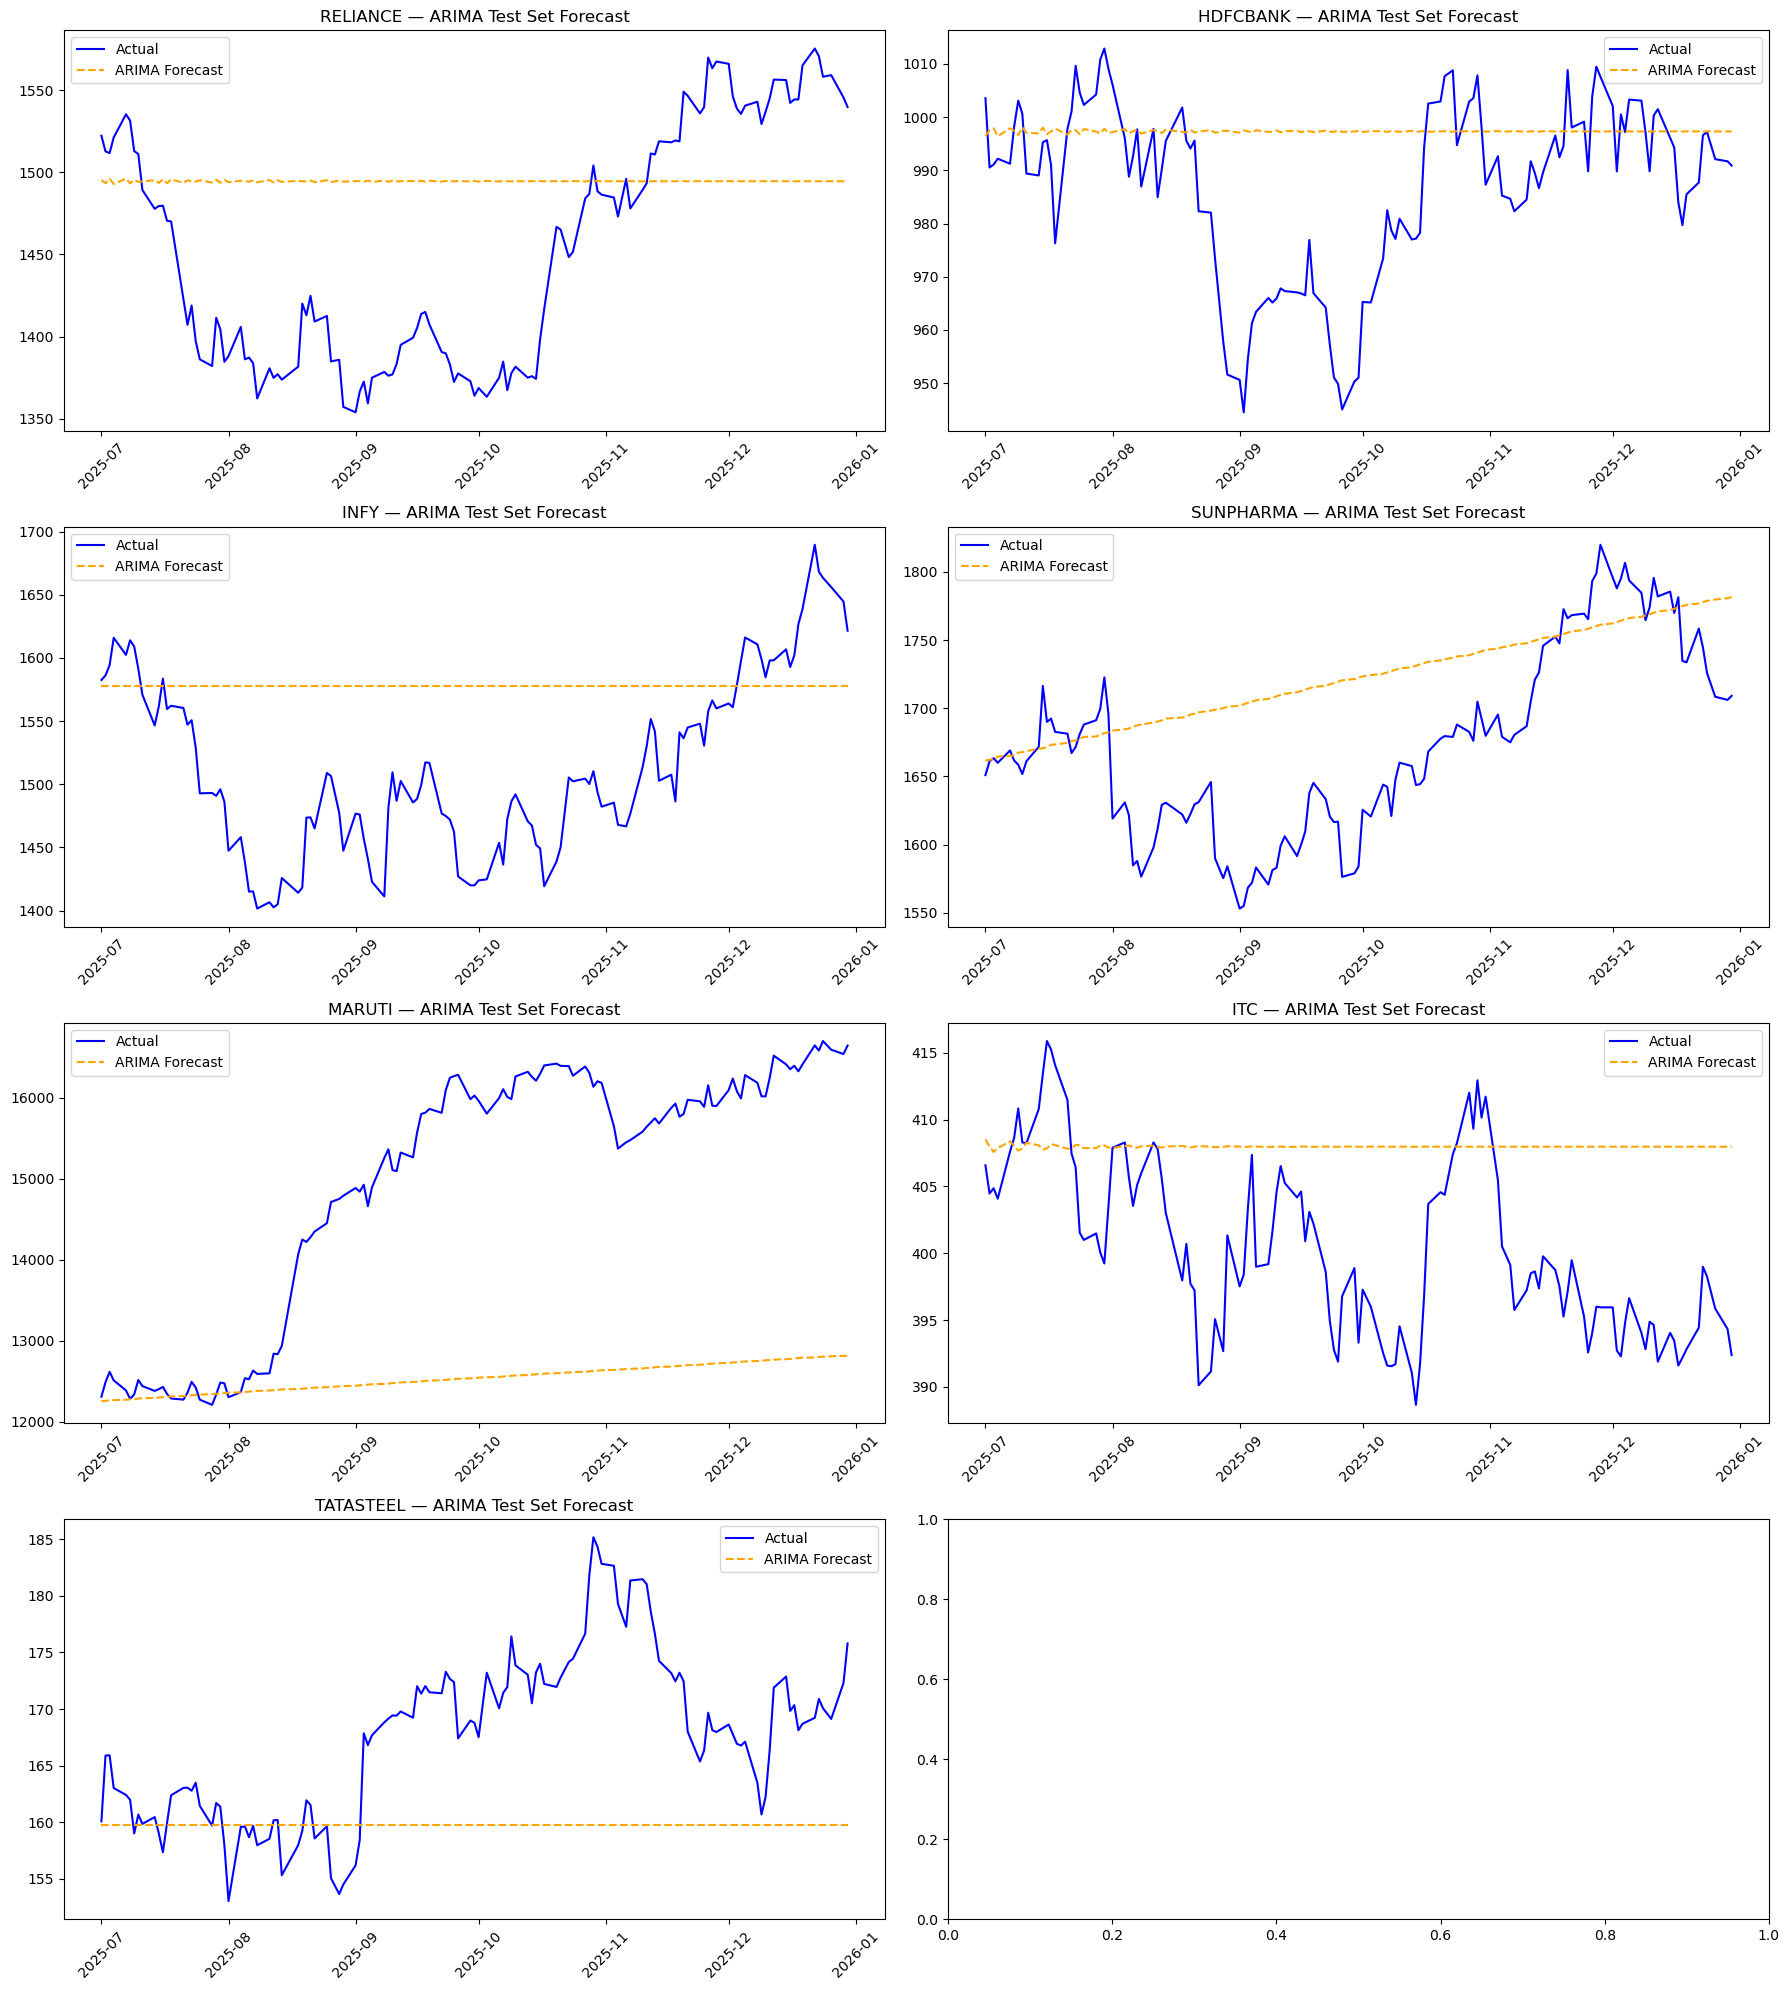

In [9]:
# ── Plot ARIMA results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, stock in enumerate(close_prices.columns):
    ax = axes[idx]
    test_series  = test_prices[stock]
    test_forecast = arima_forecasts[stock]['test_forecast']
    
    ax.plot(test_series.index, test_series.values, label='Actual', color='blue')
    ax.plot(test_series.index, test_forecast.values, label='ARIMA Forecast', color='orange', linestyle='--')
    ax.set_title(f'{stock} — ARIMA Test Set Forecast')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('task3_arima_results.png', dpi=150)
plt.show()

In [10]:
from prophet import Prophet

def fit_prophet(train_df, stock_name, forecast_steps=5):
    """
    Fits Facebook Prophet model.
    train_df must have columns: ds (datetime), y (price)
    """
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05,   # Controls trend flexibility
        seasonality_prior_scale=10.0
    )
    model.fit(train_df)
    
    future = model.make_future_dataframe(periods=forecast_steps, freq='B')  # Business days
    forecast = model.predict(future)
    
    return model, forecast


prophet_forecasts = {}
prophet_metrics   = {}

for stock in close_prices.columns:
    print(f"\nFitting Prophet for {stock}...")
    
    # Prepare Prophet-format dataframe
    train_series = train_prices[stock].dropna().reset_index()
    train_series.columns = ['ds', 'y']
    train_series['ds'] = pd.to_datetime(train_series['ds']).dt.tz_localize(None)
    
    test_series = test_prices[stock].dropna()
    
    model, forecast = fit_prophet(train_series, stock, forecast_steps=len(test_series) + 2)
    
    # Align forecast with test period
    forecast_indexed = forecast.set_index('ds')
    
    # Get test period forecasts
    test_index_tz_naive = test_series.index.tz_localize(None)
    overlap = forecast_indexed.loc[
        forecast_indexed.index.isin(test_index_tz_naive), 'yhat'
    ]
    
    if len(overlap) > 0:
        min_len = min(len(test_series), len(overlap))
        actual  = test_series.values[:min_len]
        pred    = overlap.values[:min_len]
        
        mape    = np.mean(np.abs((actual - pred) / actual)) * 100
        rmse    = np.sqrt(np.mean((actual - pred) ** 2))
        dir_acc = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(pred))) * 100
    else:
        mape, rmse, dir_acc = np.nan, np.nan, np.nan
    
    # Next 2 trading day forecasts (last 2 rows of future forecast)
    next2 = forecast.tail(2)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    
    prophet_forecasts[stock] = {
        'model': model,
        'full_forecast': forecast,
        'next_2_days': next2
    }
    prophet_metrics[stock] = {'MAPE': mape, 'RMSE': rmse, 'Dir_Acc': dir_acc}
    print(f"  MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | Dir Acc: {dir_acc:.1f}%")


Fitting Prophet for RELIANCE...


12:00:46 - cmdstanpy - INFO - Chain [1] start processing
12:00:47 - cmdstanpy - INFO - Chain [1] done processing


  MAPE: 12.15% | RMSE: 218.89 | Dir Acc: 51.2%

Fitting Prophet for HDFCBANK...


12:00:47 - cmdstanpy - INFO - Chain [1] start processing
12:00:48 - cmdstanpy - INFO - Chain [1] done processing


  MAPE: 3.62% | RMSE: 41.18 | Dir Acc: 55.4%

Fitting Prophet for INFY...


...

  MAPE: 17.11% | RMSE: 3184.74 | Dir Acc: 53.7%

Fitting Prophet for ITC...


12:00:52 - cmdstanpy - INFO - Chain [1] done processing
12:00:53 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 3.96% | RMSE: 18.42 | Dir Acc: 49.6%

Fitting Prophet for TATASTEEL...


12:00:53 - cmdstanpy - INFO - Chain [1] done processing


  MAPE: 18.89% | RMSE: 34.43 | Dir Acc: 50.4%


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def create_sequences(data, lookback=60):
    """Create sliding window sequences for LSTM input."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)


def build_lstm_model(lookback=60):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


lstm_forecasts = {}
lstm_metrics   = {}
LOOKBACK = 60

for stock in close_prices.columns:
    print(f"\nTraining LSTM for {stock}...")
    
    scaler = scalers[stock]
    
    # Prepare full scaled series
    full_scaled = scaler.transform(close_prices[[stock]].dropna()).flatten()
    
    # Split at same point as before
    n_train = len(train_prices[stock].dropna())
    train_s = full_scaled[:n_train]
    test_s  = full_scaled[n_train:]
    
    # Create sequences from training data
    X_train, y_train = create_sequences(train_s, LOOKBACK)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    
    # Build and train
    model = build_lstm_model(LOOKBACK)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    # ── Predict on test set (one step at a time) ───────────────────────────────
    # Use rolling prediction: feed actual past values
    combined = full_scaled  # Full series (train + test)
    predictions_scaled = []
    
    for i in range(n_train, len(combined)):
        x_input = combined[i - LOOKBACK:i].reshape(1, LOOKBACK, 1)
        pred = model.predict(x_input, verbose=0)[0][0]
        predictions_scaled.append(pred)
    
    # Inverse transform
    predictions = scaler.inverse_transform(
        np.array(predictions_scaled).reshape(-1, 1)
    ).flatten()
    
    test_actual = test_prices[stock].dropna().values[:len(predictions)]
    
    mape    = np.mean(np.abs((test_actual - predictions) / test_actual)) * 100
    rmse    = np.sqrt(np.mean((test_actual - predictions) ** 2))
    dir_acc = np.mean(np.sign(np.diff(test_actual)) == np.sign(np.diff(predictions))) * 100
    
    # ── Forecast next 2 days ───────────────────────────────────────────────────
    last_window = full_scaled[-LOOKBACK:]
    next_2 = []
    window = last_window.copy()
    
    for _ in range(2):
        x = window.reshape(1, LOOKBACK, 1)
        p = model.predict(x, verbose=0)[0][0]
        next_2.append(p)
        window = np.append(window[1:], p)
    
    next_2_prices = scaler.inverse_transform(
        np.array(next_2).reshape(-1, 1)
    ).flatten()
    
    lstm_forecasts[stock] = {
        'model': model,
        'test_predictions': predictions,
        'next_2_days': next_2_prices
    }
    lstm_metrics[stock] = {'MAPE': mape, 'RMSE': rmse, 'Dir_Acc': dir_acc}
    print(f"  MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | Dir Acc: {dir_acc:.1f}%")


Training LSTM for RELIANCE...
  MAPE: 2.21% | RMSE: 40.89 | Dir Acc: 46.8%

Training LSTM for HDFCBANK...
  MAPE: 1.49% | RMSE: 17.21 | Dir Acc: 48.4%

Training LSTM for INFY...
  MAPE: 1.58% | RMSE: 29.22 | Dir Acc: 50.0%

Training LSTM for SUNPHARMA...
  MAPE: 1.72% | RMSE: 35.44 | Dir Acc: 50.8%

Training LSTM for MARUTI...
  MAPE: 4.30% | RMSE: 786.73 | Dir Acc: 54.0%

Training LSTM for ITC...
  MAPE: 1.22% | RMSE: 5.86 | Dir Acc: 43.5%

Training LSTM for TATASTEEL...
  MAPE: 9.24% | RMSE: 16.53 | Dir Acc: 45.2%



Volatility & Trend Analysis: RELIANCE
  Recent 30-day Rolling Vol: 0.7646%
  GARCH next-2-day vol forecast: [1.0198297  1.02973944]
  Trend direction (last 30 days): DOWNWARD
  Trend strength: 0.66%


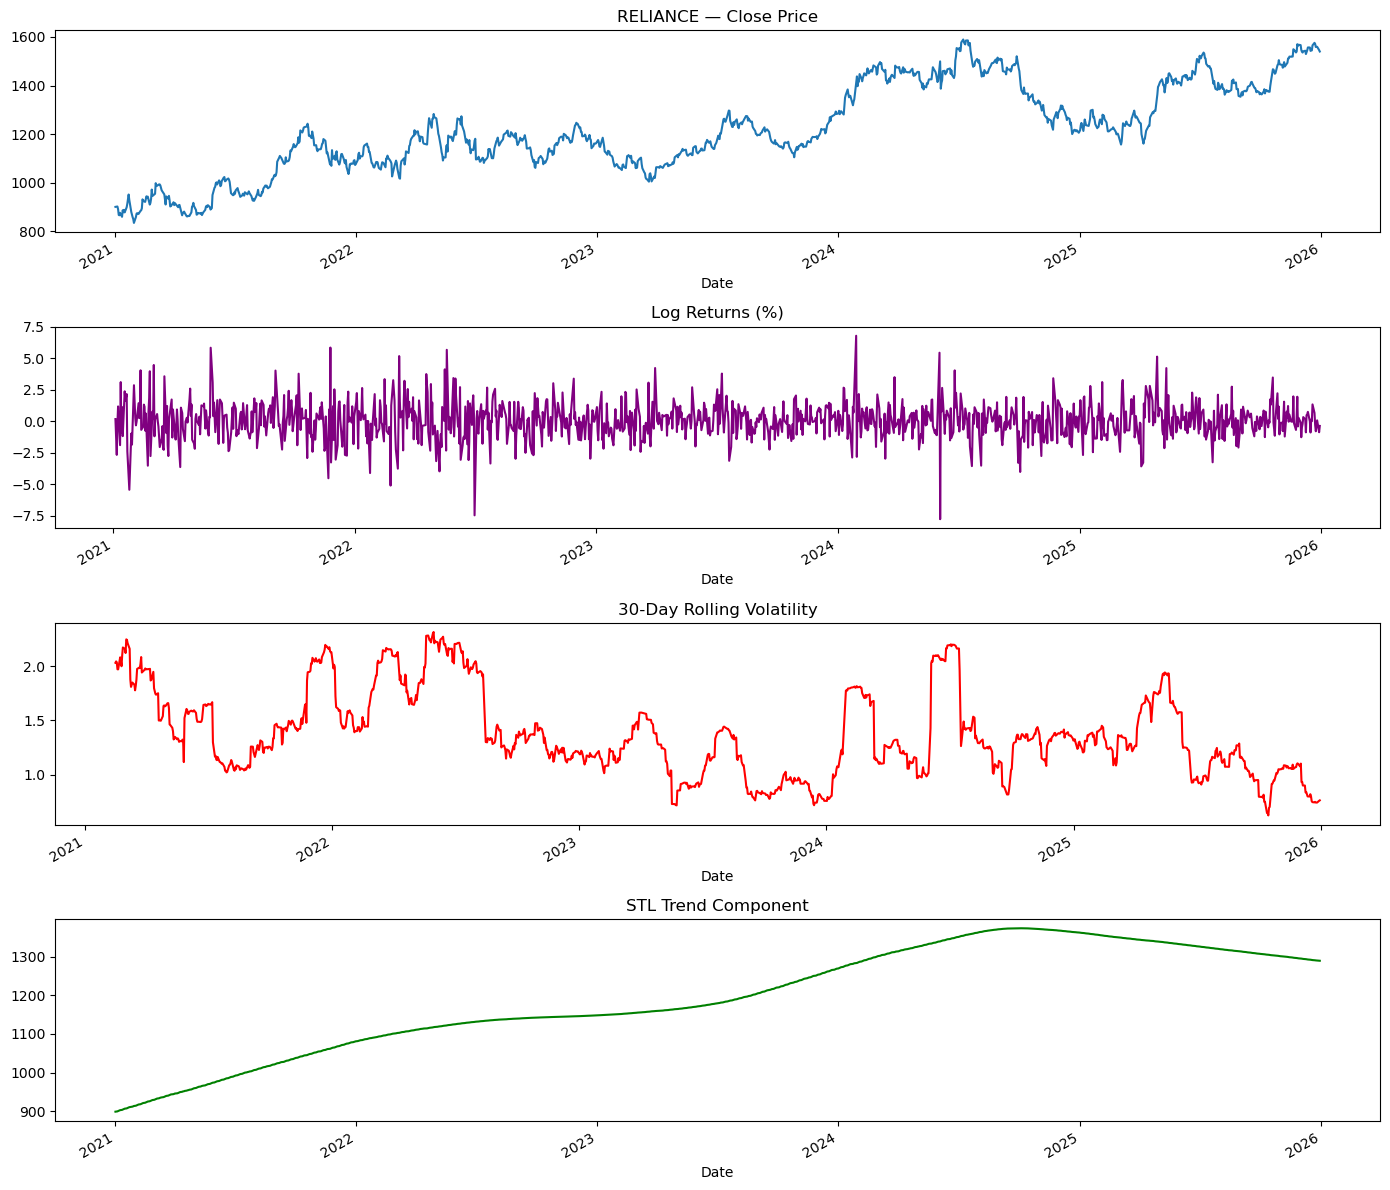


Volatility & Trend Analysis: HDFCBANK
  Recent 30-day Rolling Vol: 0.7239%
  GARCH next-2-day vol forecast: [0.93759032 0.95202536]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.69%


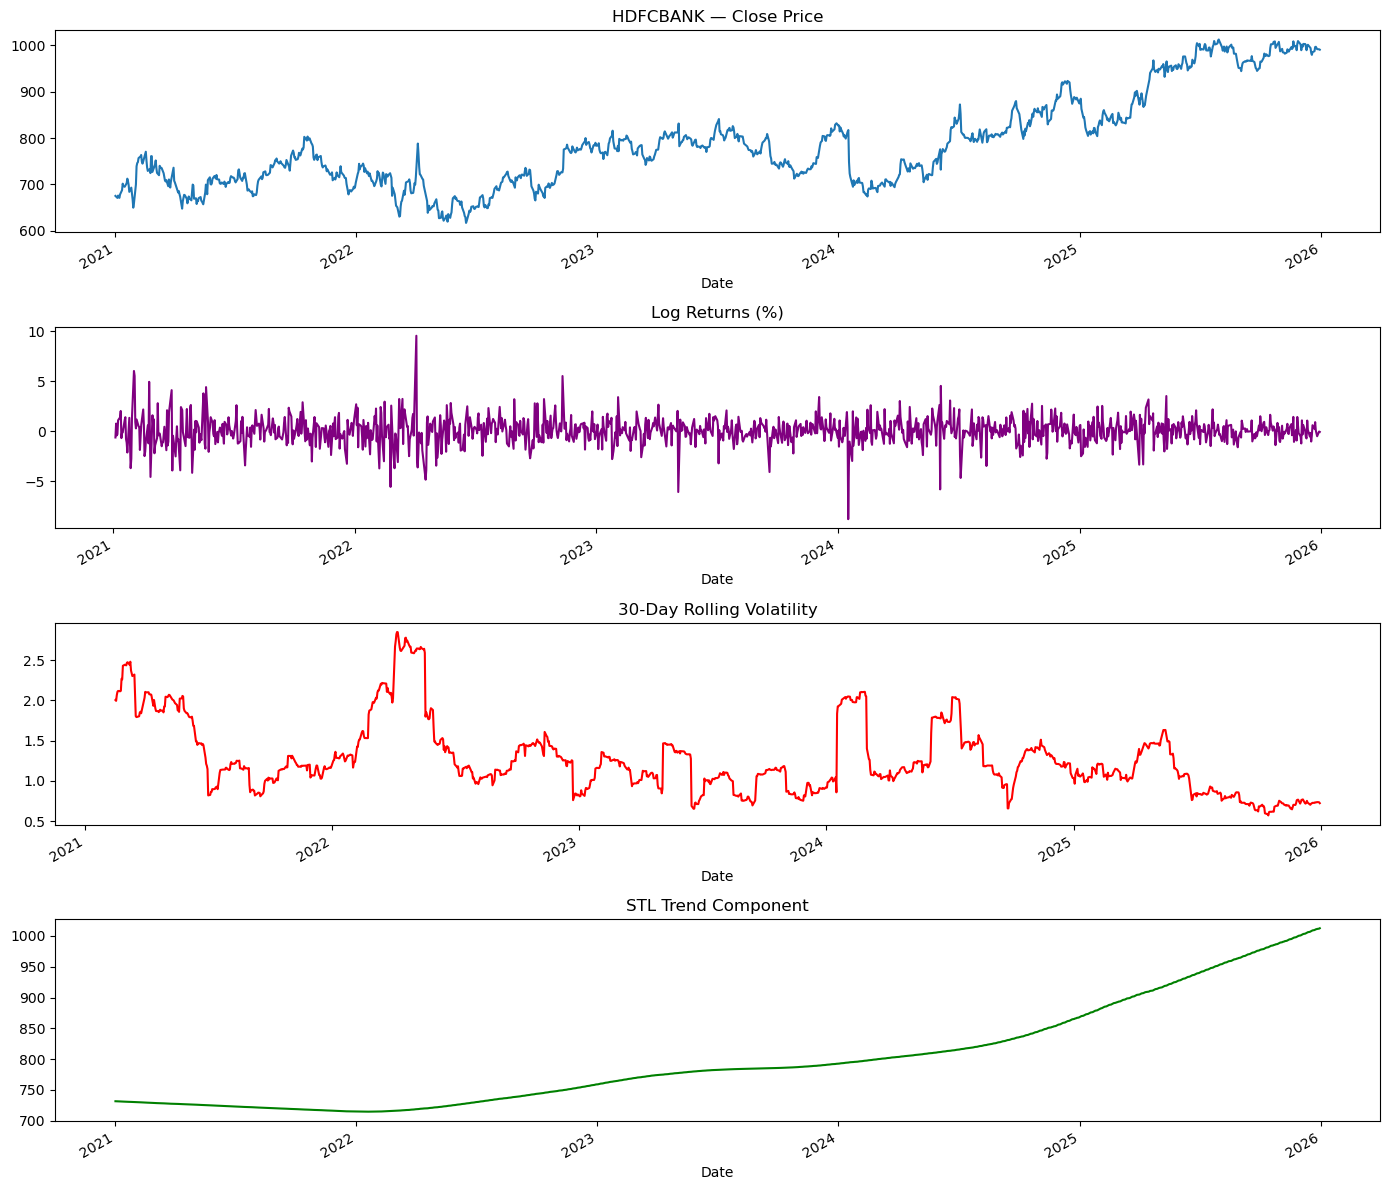


Volatility & Trend Analysis: INFY
  Recent 30-day Rolling Vol: 1.2153%
  GARCH next-2-day vol forecast: [1.51913792 1.52655692]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.12%


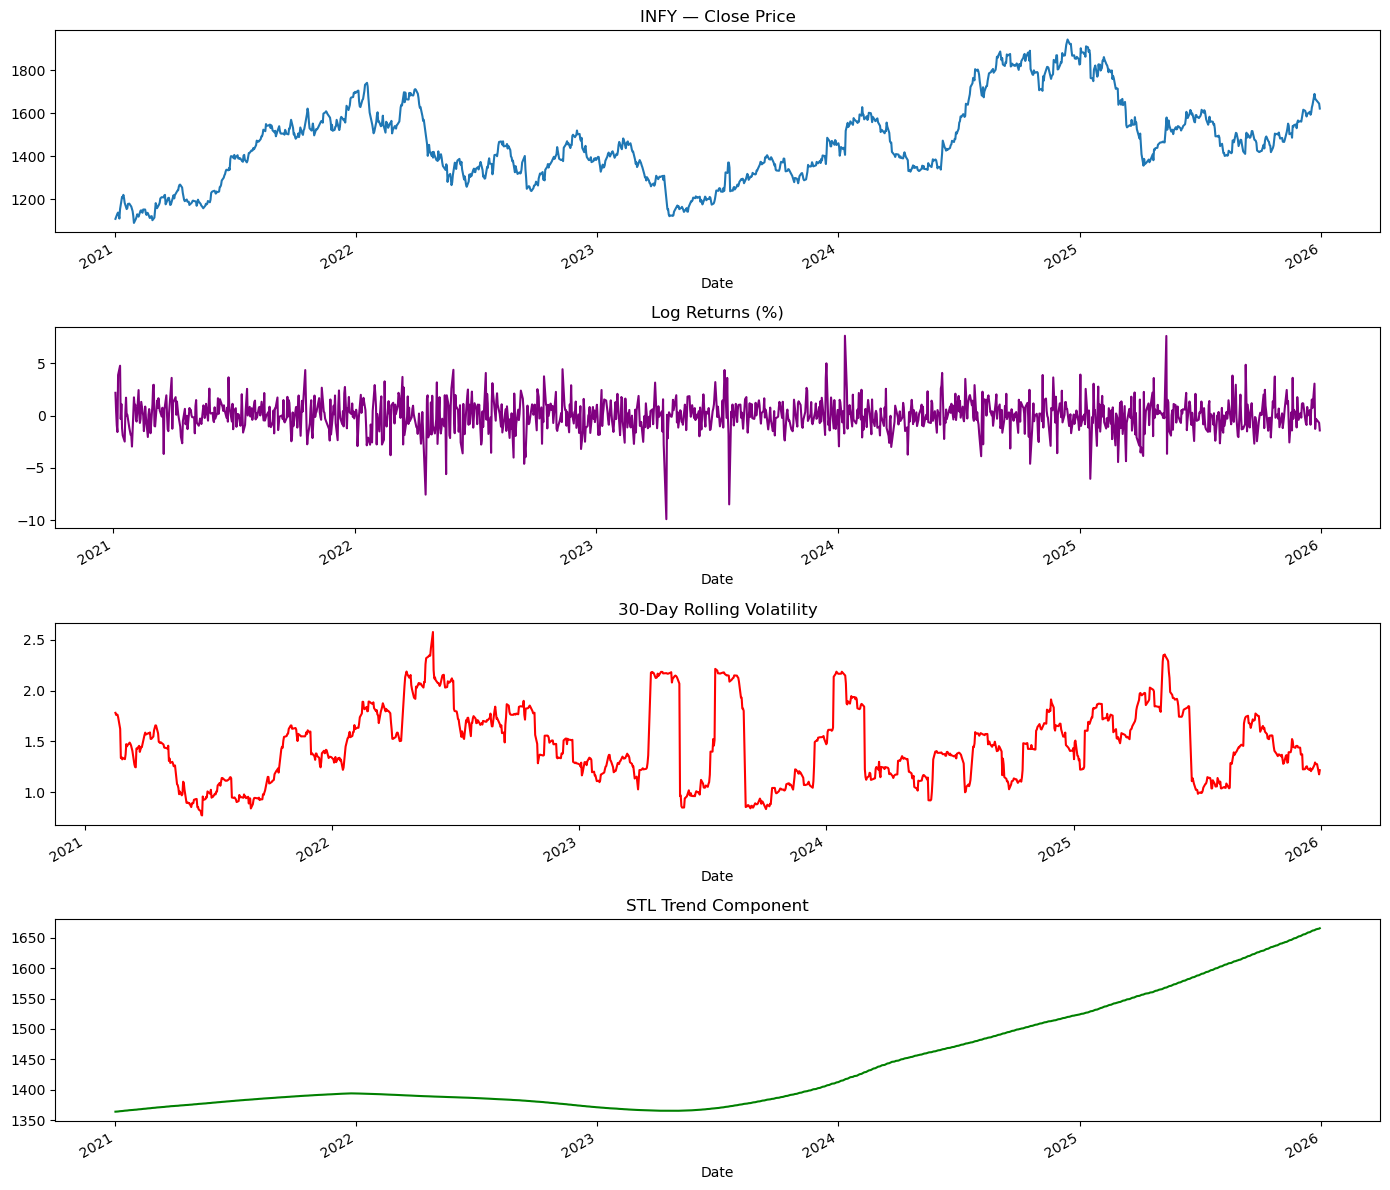


Volatility & Trend Analysis: SUNPHARMA
  Recent 30-day Rolling Vol: 0.9491%
  GARCH next-2-day vol forecast: [1.10189932 1.10227318]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.62%


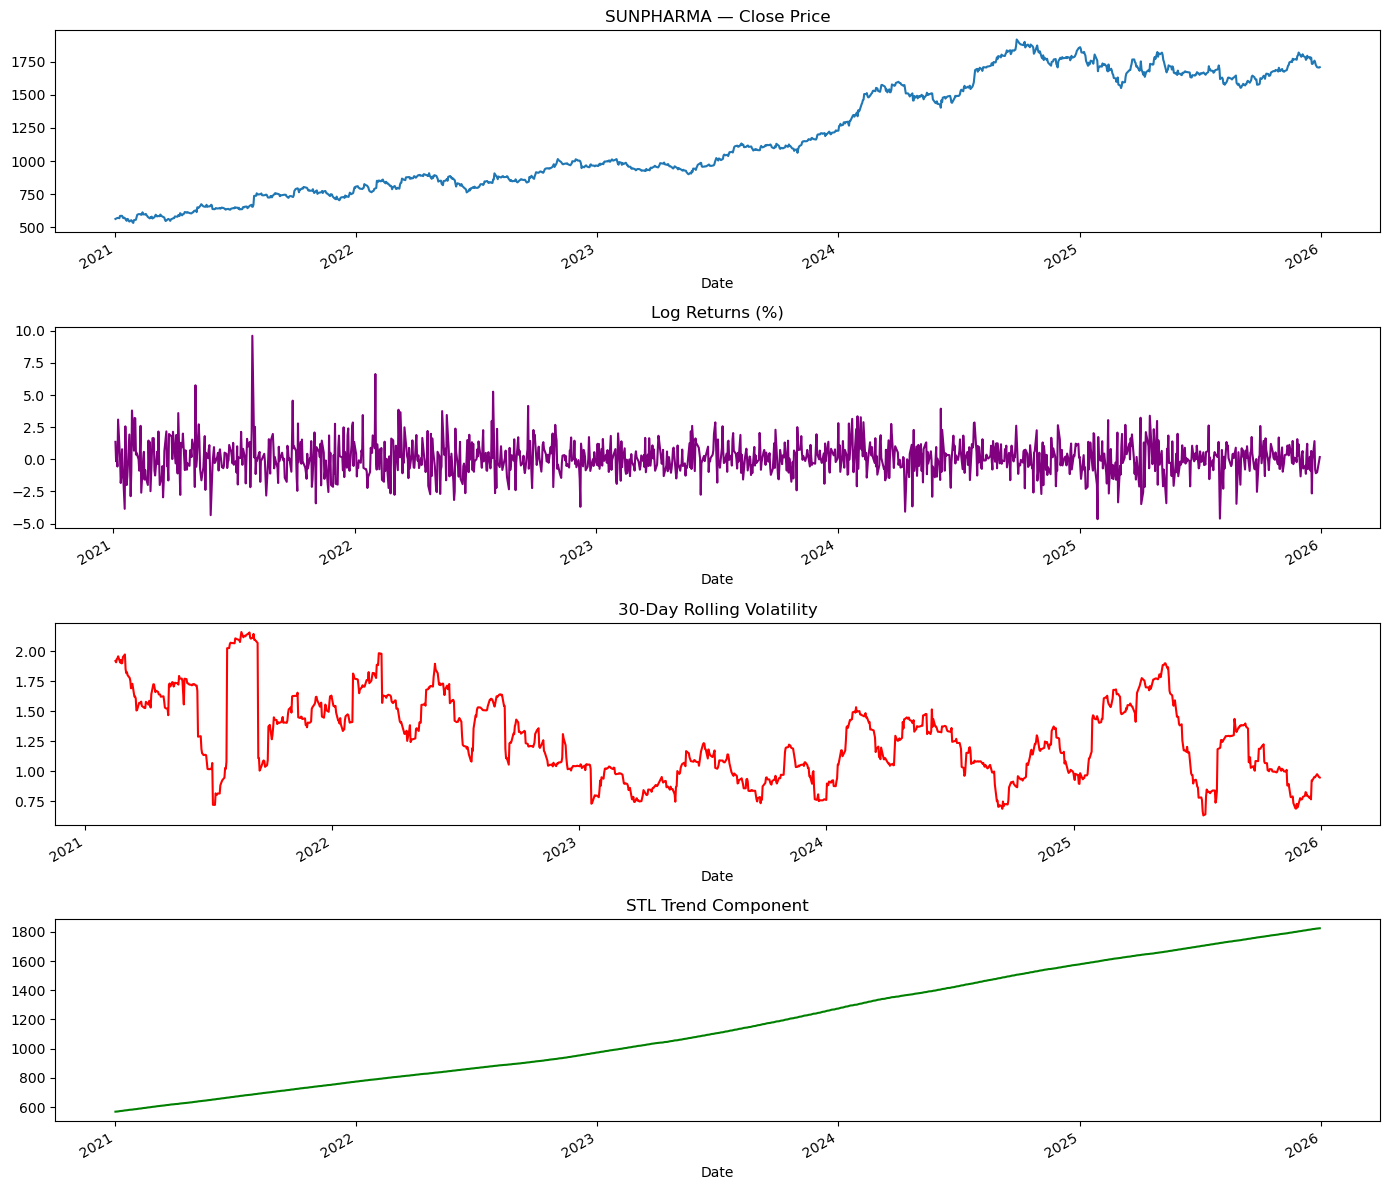


Volatility & Trend Analysis: MARUTI
  Recent 30-day Rolling Vol: 0.9241%
  GARCH next-2-day vol forecast: [1.1676631  1.16986024]
  Trend direction (last 30 days): UPWARD
  Trend strength: 2.11%


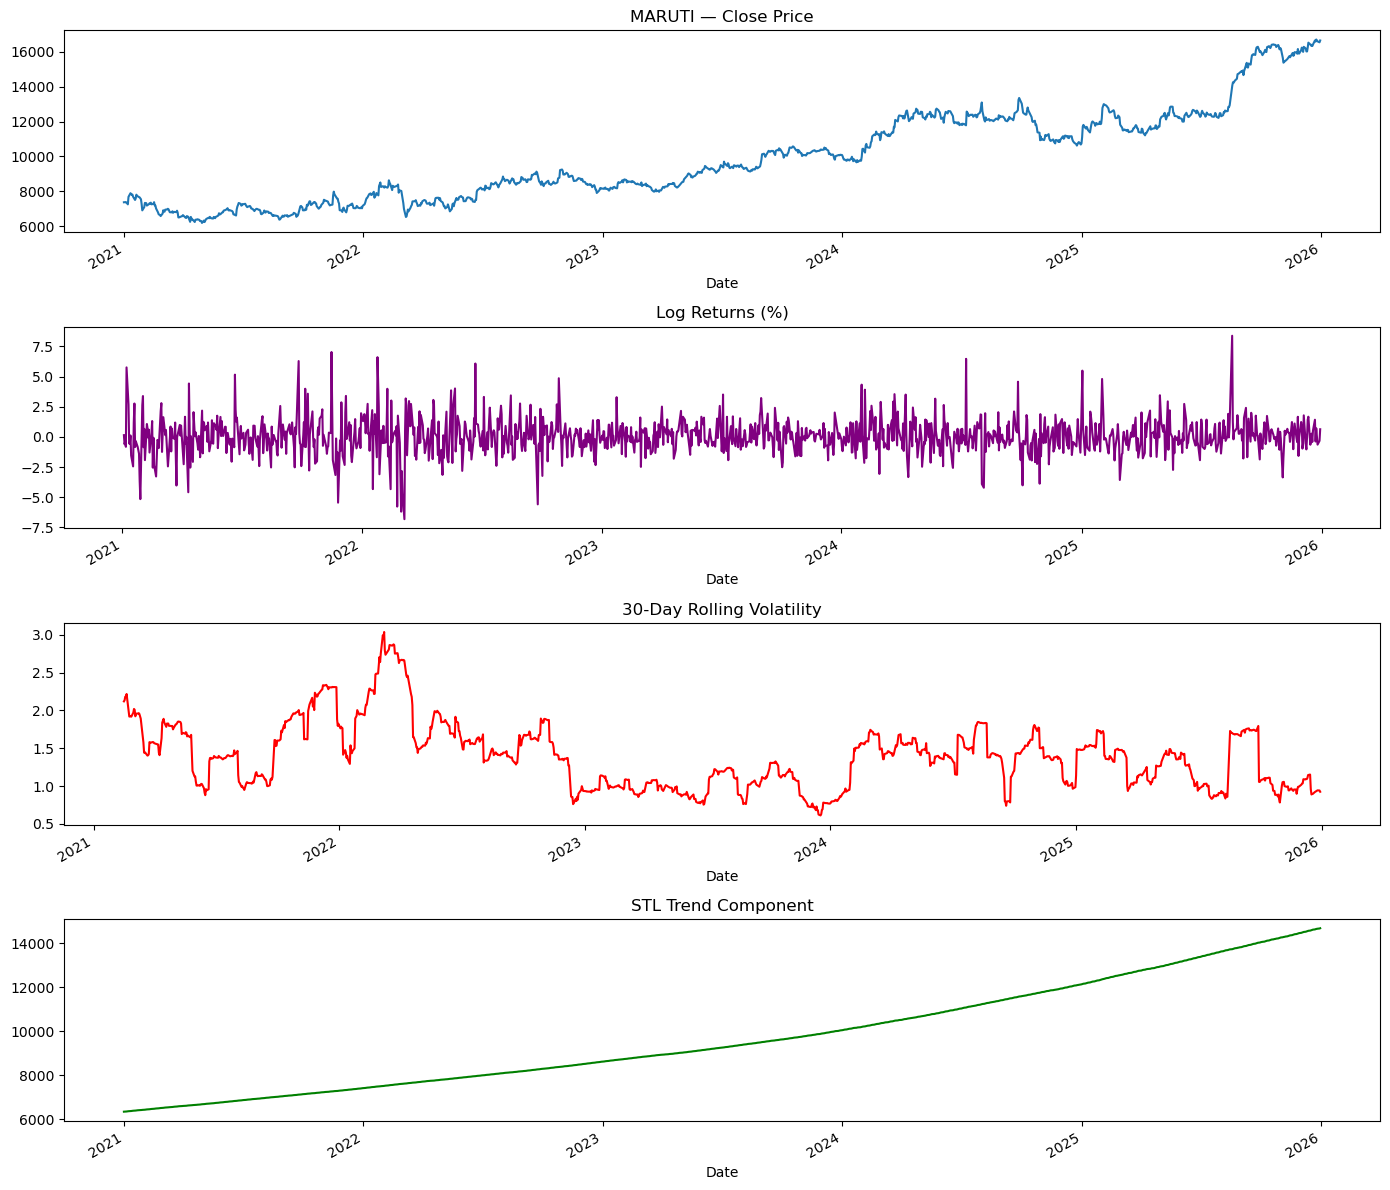


Volatility & Trend Analysis: ITC
  Recent 30-day Rolling Vol: 0.5367%
  GARCH next-2-day vol forecast: [1.00403381 1.0483896 ]
  Trend direction (last 30 days): DOWNWARD
  Trend strength: 0.23%


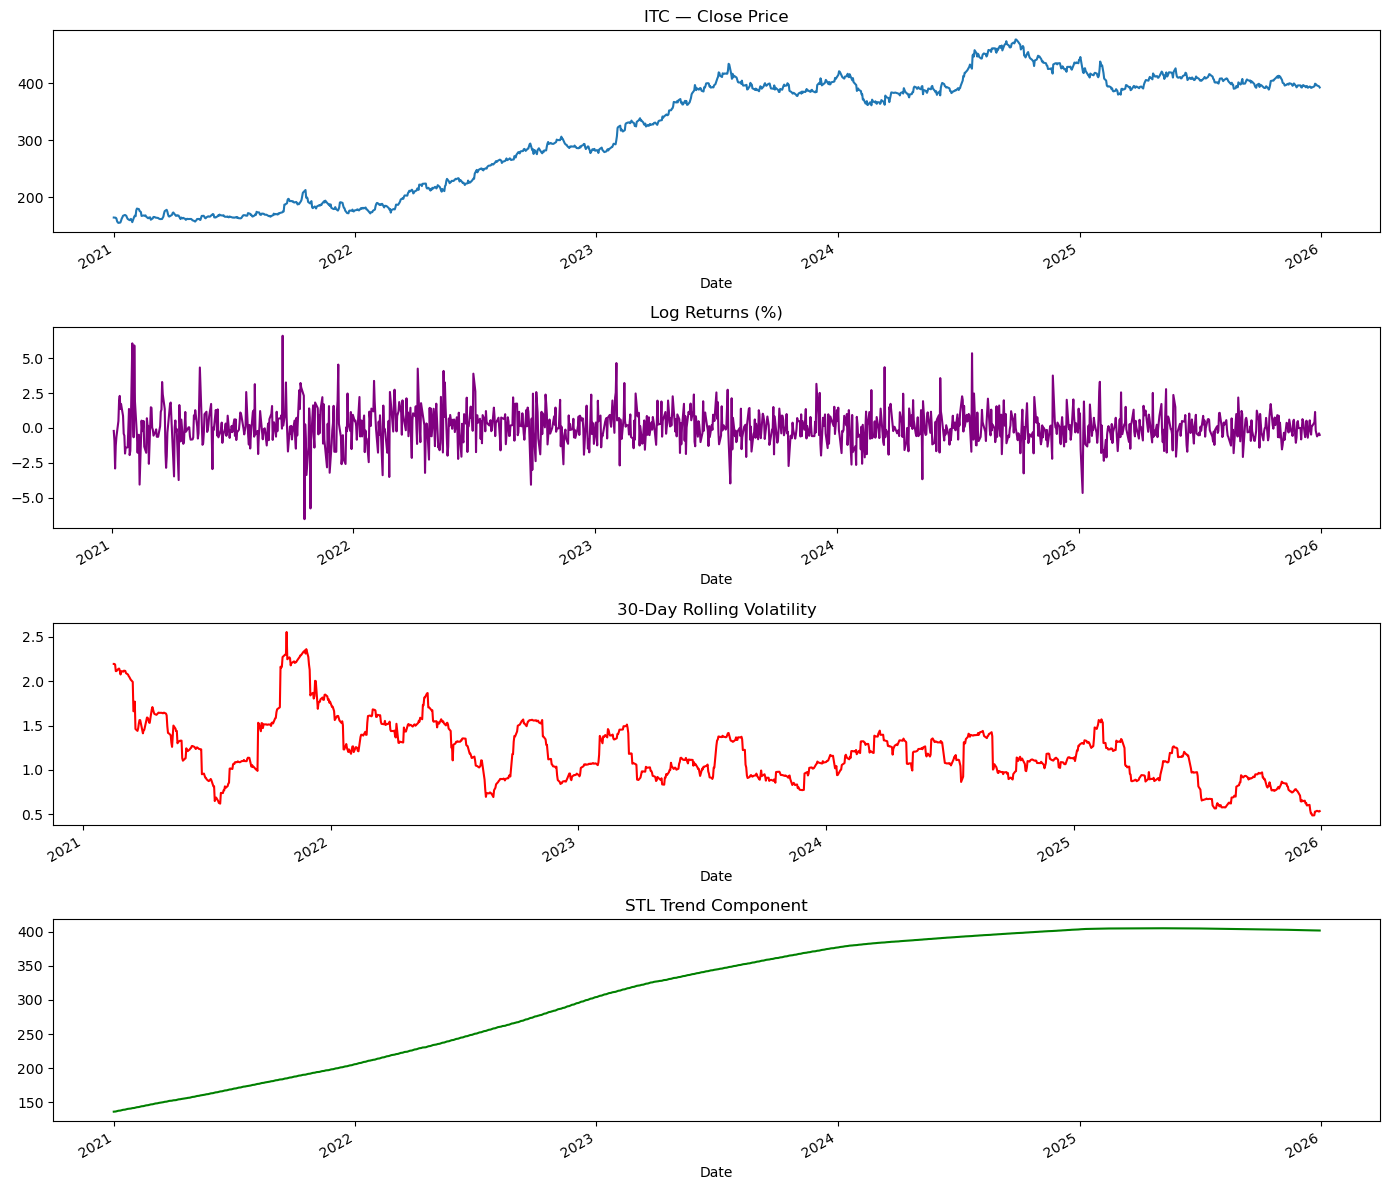


Volatility & Trend Analysis: TATASTEEL
  Recent 30-day Rolling Vol: 1.3898%
  GARCH next-2-day vol forecast: [1.5282679  1.53351761]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.63%


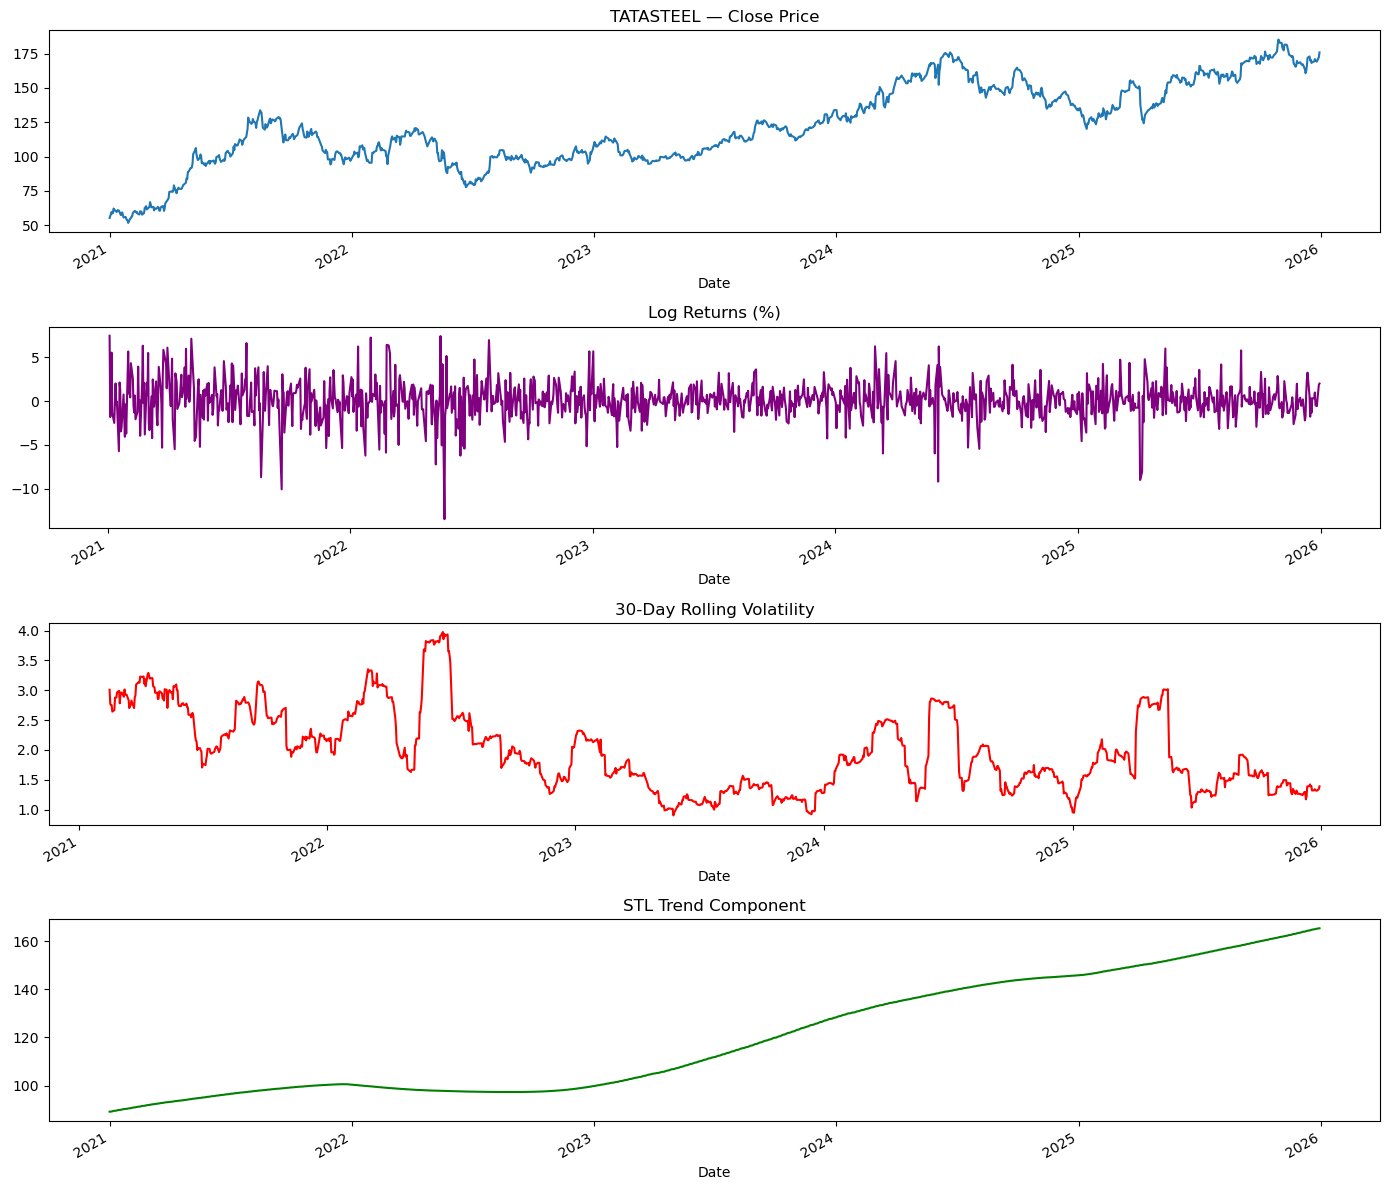

In [12]:
from arch import arch_model
from statsmodels.tsa.seasonal import STL

volatility_results = {}

for stock in close_prices.columns:
    print(f"\n{'='*50}")
    print(f"Volatility & Trend Analysis: {stock}")
    
    series = close_prices[stock].dropna()
    
    # ── 1. Log Returns ─────────────────────────────────────────────────────────
    log_ret = np.log(series / series.shift(1)).dropna() * 100  # In percentage
    
    # ── 2. Rolling Standard Deviation (30-day) ─────────────────────────────────
    rolling_vol = log_ret.rolling(window=30).std()
    recent_vol  = rolling_vol.iloc[-1]
    print(f"  Recent 30-day Rolling Vol: {recent_vol:.4f}%")
    
    # ── 3. GARCH(1,1) ──────────────────────────────────────────────────────────
    try:
        garch = arch_model(log_ret, vol='Garch', p=1, q=1, dist='normal')
        garch_fit = garch.fit(disp='off')
        garch_forecast = garch_fit.forecast(horizon=2)
        garch_vol_next2 = np.sqrt(garch_forecast.variance.values[-1])  # Std dev forecast
        print(f"  GARCH next-2-day vol forecast: {garch_vol_next2}")
    except Exception as e:
        print(f"  GARCH failed: {e}")
        garch_vol_next2 = np.array([recent_vol, recent_vol])
    
    # ── 4. STL Decomposition ───────────────────────────────────────────────────
    stl = STL(series, period=252, robust=True)
    stl_result = stl.fit()
    
    trend_series = stl_result.trend
    trend_direction = 'UPWARD' if trend_series.iloc[-1] > trend_series.iloc[-30] else 'DOWNWARD'
    trend_strength = abs(trend_series.iloc[-1] - trend_series.iloc[-30]) / trend_series.iloc[-30] * 100
    
    print(f"  Trend direction (last 30 days): {trend_direction}")
    print(f"  Trend strength: {trend_strength:.2f}%")
    
    # Store results
    volatility_results[stock] = {
        'log_returns': log_ret,
        'rolling_vol_30d': rolling_vol,
        'recent_vol': recent_vol,
        'garch_next2_vol': garch_vol_next2,
        'trend_direction': trend_direction,
        'trend_strength': trend_strength,
        'stl': stl_result
    }
    
    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    
    series.plot(ax=axes[0], title=f'{stock} — Close Price')
    log_ret.plot(ax=axes[1], title='Log Returns (%)', color='purple')
    rolling_vol.plot(ax=axes[2], title='30-Day Rolling Volatility', color='red')
    stl_result.trend.plot(ax=axes[3], title='STL Trend Component', color='green')
    
    plt.tight_layout()
    plt.savefig(f'task4_volatility_{stock}.png', dpi=100)
    plt.show()

In [13]:
TOTAL_CAPITAL = 1_000_000  # ₹10,00,000

# ── Strategy A: Forecast-Guided (predicted 2-day return) ──────────────────────
# Use ensemble of ARIMA + Prophet + LSTM average as the forecast

predicted_returns = {}
last_known_price  = {}

for stock in close_prices.columns:
    last_price = close_prices[stock].dropna().iloc[-1]
    last_known_price[stock] = last_price
    
    # Get day-2 forecasts from each model
    arima_d2   = arima_forecasts[stock]['next_2_days'].iloc[-1]
    prophet_d2 = prophet_forecasts[stock]['next_2_days']['yhat'].iloc[-1]
    lstm_d2    = lstm_forecasts[stock]['next_2_days'][-1]
    
    # Ensemble: simple average
    ensemble_d2 = np.mean([arima_d2, prophet_d2, lstm_d2])
    pred_return = (ensemble_d2 - last_price) / last_price * 100
    predicted_returns[stock] = pred_return
    
    print(f"{stock:12s} | Last: ₹{last_price:8.2f} | "
          f"ARIMA: ₹{arima_d2:8.2f} | Prophet: ₹{prophet_d2:8.2f} | "
          f"LSTM: ₹{lstm_d2:8.2f} | Ensemble D2: ₹{ensemble_d2:8.2f} | "
          f"Predicted Return: {pred_return:+.2f}%")

RELIANCE     | Last: ₹ 1539.80 | ARIMA: ₹ 1493.44 | Prophet: ₹ 1153.19 | LSTM: ₹ 1539.98 | Ensemble D2: ₹ 1395.53 | Predicted Return: -9.37%
HDFCBANK     | Last: ₹  990.90 | ARIMA: ₹  997.54 | Prophet: ₹ 1067.21 | LSTM: ₹  975.97 | Ensemble D2: ₹ 1013.57 | Predicted Return: +2.29%
INFY         | Last: ₹ 1621.60 | ARIMA: ₹ 1577.65 | Prophet: ₹ 1688.13 | LSTM: ₹ 1638.54 | Ensemble D2: ₹ 1634.77 | Predicted Return: +0.81%
SUNPHARMA    | Last: ₹ 1709.10 | ARIMA: ₹ 1662.31 | Prophet: ₹ 1840.32 | LSTM: ₹ 1737.23 | Ensemble D2: ₹ 1746.62 | Predicted Return: +2.20%
MARUTI       | Last: ₹16647.00 | ARIMA: ₹12257.40 | Prophet: ₹11497.34 | LSTM: ₹15636.77 | Ensemble D2: ₹13130.50 | Predicted Return: -21.12%
ITC          | Last: ₹  392.38 | ARIMA: ₹  407.97 | Prophet: ₹  398.69 | LSTM: ₹  396.03 | Ensemble D2: ₹  400.90 | Predicted Return: +2.17%
TATASTEEL    | Last: ₹  175.80 | ARIMA: ₹  159.76 | Prophet: ₹  125.58 | LSTM: ₹  153.26 | Ensemble D2: ₹  146.20 | Predicted Return: -16.84%


In [14]:
# ── Strategy B: Volatility-Aware Sizing ───────────────────────────────────────
# Weight inversely proportional to recent volatility

vol_dict = {stock: volatility_results[stock]['recent_vol'] for stock in close_prices.columns}
inv_vol  = {stock: 1.0 / v for stock, v in vol_dict.items()}
inv_vol_sum = sum(inv_vol.values())
vol_weights = {stock: inv_vol[stock] / inv_vol_sum for stock in close_prices.columns}

# ── Combine Strategy A + B ─────────────────────────────────────────────────────
# Only invest in stocks with POSITIVE predicted returns
# Combine: 60% weight from A (return ranking), 40% from B (vol sizing)

# Strategy A weights: proportional to positive predicted return
pos_returns = {s: max(r, 0) for s, r in predicted_returns.items()}
pos_sum = sum(pos_returns.values())

if pos_sum == 0:
    # If all negative, use smallest magnitude losses
    pos_returns = {s: 1.0 for s in close_prices.columns}
    pos_sum = sum(pos_returns.values())

ret_weights = {s: pos_returns[s] / pos_sum for s in close_prices.columns}

# Final combined weight
alpha = 0.6  # Weight on forecast-guided
beta  = 0.4  # Weight on volatility-aware

final_weights = {}
for stock in close_prices.columns:
    final_weights[stock] = alpha * ret_weights[stock] + beta * vol_weights[stock]

# Normalize to sum = 1
weight_sum = sum(final_weights.values())
final_weights = {s: w / weight_sum for s, w in final_weights.items()}

In [15]:
# ── Build Allocation Table ─────────────────────────────────────────────────────
allocation_table = []

for stock in close_prices.columns:
    w       = final_weights[stock]
    amount  = w * TOTAL_CAPITAL
    price   = last_known_price[stock]
    shares  = int(amount // price)   # Whole shares only
    actual_amount = shares * price
    
    allocation_table.append({
        'Stock': stock,
        'Sector': {
            'RELIANCE': 'Energy', 'HDFCBANK': 'Banking', 'INFY': 'IT',
            'SUNPHARMA': 'Pharma', 'MARUTI': 'Auto',
            'ITC': 'FMCG', 'TATASTEEL': 'Metals'
        }[stock],
        'Last Price (₹)': round(price, 2),
        'Predicted 2-Day Return (%)': round(predicted_returns[stock], 2),
        'Recent Volatility (%)': round(vol_dict[stock], 4),
        'Weight (%)': round(w * 100, 2),
        'Allocated Amount (₹)': round(actual_amount, 2),
        'Shares to Buy': shares
    })

alloc_df = pd.DataFrame(allocation_table)
total_deployed = alloc_df['Allocated Amount (₹)'].sum()
alloc_df.loc[len(alloc_df)] = ['TOTAL', '', '', '', '', 100.0, round(total_deployed, 2), '']

print(alloc_df.to_string(index=False))
alloc_df.to_csv('../outputs/day2_portfolio_allocation.csv', index=False)

    Stock  Sector Last Price (₹) Predicted 2-Day Return (%) Recent Volatility (%)  Weight (%)  Allocated Amount (₹) Shares to Buy
 RELIANCE  Energy         1539.8                      -9.37                0.7646        6.36              63131.80            41
 HDFCBANK Banking          990.9                       2.29                0.7239       25.10             250697.71           253
     INFY      IT         1621.6                       0.81                1.2153       10.53             103782.40            64
SUNPHARMA  Pharma         1709.1                        2.2                0.9491       22.76             227310.04           133
   MARUTI    Auto        16647.0                     -21.12                0.9241        5.26              49941.00             3
      ITC    FMCG         392.38                       2.17                0.5367       26.50             264854.28           675
TATASTEEL  Metals          175.8                     -16.84                1.3898        3

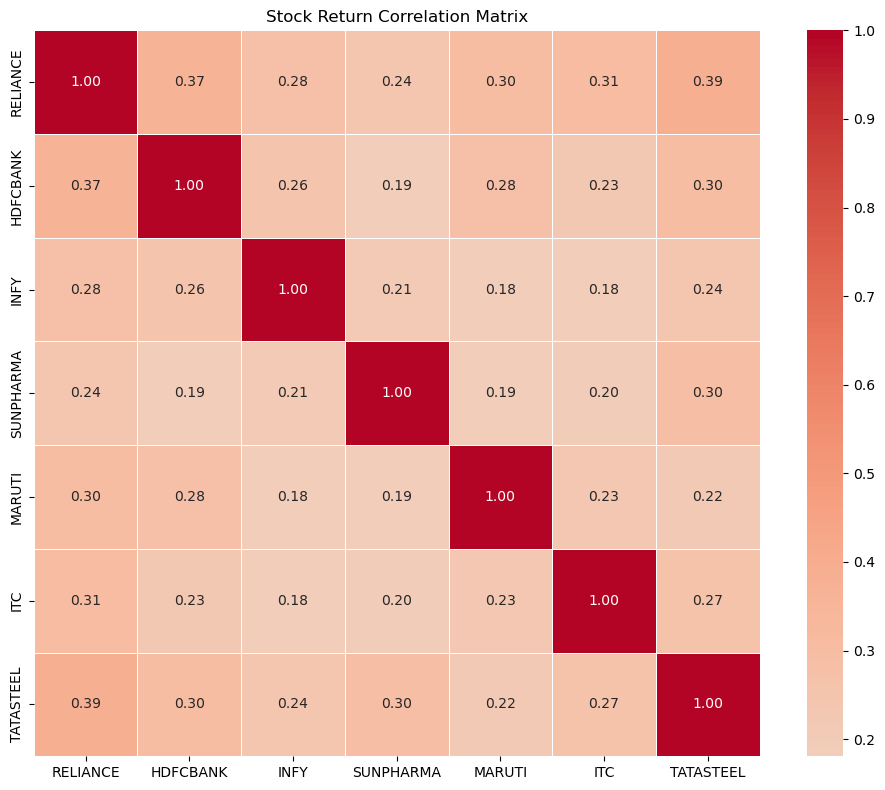


Low correlation pairs (|r| < 0.3):
  RELIANCE — INFY: 0.28
  RELIANCE — SUNPHARMA: 0.24
  RELIANCE — MARUTI: 0.30
  HDFCBANK — INFY: 0.26
  HDFCBANK — SUNPHARMA: 0.19
  HDFCBANK — MARUTI: 0.28
  HDFCBANK — ITC: 0.23
  HDFCBANK — TATASTEEL: 0.30
  INFY — SUNPHARMA: 0.21
  INFY — MARUTI: 0.18
  INFY — ITC: 0.18
  INFY — TATASTEEL: 0.24
  SUNPHARMA — MARUTI: 0.19
  SUNPHARMA — ITC: 0.20
  SUNPHARMA — TATASTEEL: 0.30
  MARUTI — ITC: 0.23
  MARUTI — TATASTEEL: 0.22
  ITC — TATASTEEL: 0.27


In [16]:
# ── Correlation Matrix (for Strategy C bonus) ─────────────────────────────────
import seaborn as sns

corr_matrix = log_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Stock Return Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/day2_task5_correlation_heatmap.png', dpi=150)
plt.show()

# Low-correlation pairs are good for diversification
print("\nLow correlation pairs (|r| < 0.3):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) < 0.3:
            print(f"  {corr_matrix.columns[i]} — {corr_matrix.columns[j]}: {val:.2f}")

In [17]:
# ── Build comprehensive comparison table ───────────────────────────────────────
comparison_rows = []

for stock in close_prices.columns:
    a_m = arima_metrics[stock]
    p_m = prophet_metrics[stock]
    l_m = lstm_metrics[stock]
    
    comparison_rows.append({
        'Stock': stock,
        'ARIMA_MAPE':     round(a_m['MAPE'], 2),
        'ARIMA_RMSE':     round(a_m['RMSE'], 2),
        'ARIMA_DirAcc':   round(a_m['Dir_Acc'], 1),
        'Prophet_MAPE':   round(p_m['MAPE'], 2) if not np.isnan(p_m['MAPE']) else 'N/A',
        'Prophet_RMSE':   round(p_m['RMSE'], 2) if not np.isnan(p_m['RMSE']) else 'N/A',
        'Prophet_DirAcc': round(p_m['Dir_Acc'], 1) if not np.isnan(p_m['Dir_Acc']) else 'N/A',
        'LSTM_MAPE':      round(l_m['MAPE'], 2),
        'LSTM_RMSE':      round(l_m['RMSE'], 2),
        'LSTM_DirAcc':    round(l_m['Dir_Acc'], 1),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv('../outputs/day2_task6_model_comparison.csv', index=False)

    Stock  ARIMA_MAPE  ARIMA_RMSE  ARIMA_DirAcc  Prophet_MAPE  Prophet_RMSE  Prophet_DirAcc  LSTM_MAPE  LSTM_RMSE  LSTM_DirAcc
 RELIANCE        5.01       82.11          54.8         12.15        218.89            51.2       2.21      40.89         46.8
 HDFCBANK        1.44       19.50          47.6          3.62         41.18            55.4       1.49      17.21         48.4
     INFY        5.41       93.74           0.8          9.32        151.94            59.5       1.58      29.22         50.0
SUNPHARMA        3.51       71.04          58.1          9.46        176.59            60.3       1.72      35.44         50.8
   MARUTI       15.14     2786.82          55.6         17.11       3184.74            53.7       4.30     786.73         54.0
      ITC        2.16       10.06          50.8          3.96         18.42            49.6       1.22       5.86         43.5
TATASTEEL        4.99       10.64           0.0         18.89         34.43            50.4       9.24      16.

## Day-2

In [27]:
# Mapping from short name to .NS symbol
name_to_symbol = {
    'RELIANCE':  'RELIANCE.NS',
    'HDFCBANK':  'HDFCBANK.NS',
    'INFY':      'INFY.NS',
    'SUNPHARMA': 'SUNPHARMA.NS',
    'MARUTI':    'MARUTI.NS',
    'ITC':       'ITC.NS',
    'TATASTEEL': 'TATASTEEL.NS'
}

# Reverse mapping: .NS symbol → short name
symbol_to_name = {v: k for k, v in name_to_symbol.items()}

# Short names list (matches arima_forecasts keys)
stock_names = list(arima_forecasts.keys())

print("Stock names:", stock_names)

Stock names: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']


In [28]:
# ============================================================
# DAY 2: FETCH LATEST PRICES
# ============================================================

latest_prices = {}

print("Fetching latest available prices...\n")

for name in stock_names:
    symbol = name_to_symbol[name]
    try:
        df = yf.download(symbol, period='5d', interval='1d', auto_adjust=True)
        
        if df.empty:
            print(f"{name:<12} ⚠️  No data found — skipping")
            continue
        
        latest_price        = float(df['Close'].iloc[-1])
        latest_date         = df.index[-1].date()
        latest_prices[name] = latest_price
        print(f"{name:<12} ({symbol:<15}) Latest Close: ₹{latest_price:>10.2f}  (as of {latest_date})")
    
    except Exception as e:
        print(f"{name:<12} ❌ Error: {e} — skipping")

print(f"\nTotal stocks fetched: {len(latest_prices)}")
print("Note: Use these as your reference prices for today's trades.")

Fetching latest available prices...



[*********************100%***********************]  1 of 1 completed


RELIANCE     (RELIANCE.NS    ) Latest Close: ₹   1381.10  (as of 2026-05-12)


[*********************100%***********************]  1 of 1 completed


HDFCBANK     (HDFCBANK.NS    ) Latest Close: ₹    753.20  (as of 2026-05-12)


...

MARUTI       (MARUTI.NS      ) Latest Close: ₹  13291.00  (as of 2026-05-12)


[*********************100%***********************]  1 of 1 completed


ITC          (ITC.NS         ) Latest Close: ₹    304.45  (as of 2026-05-12)


[*********************100%***********************]  1 of 1 completed

TATASTEEL    (TATASTEEL.NS   ) Latest Close: ₹    212.86  (as of 2026-05-12)

Total stocks fetched: 7
Note: Use these as your reference prices for today's trades.


In [30]:
# Check prophet_forecasts structure
print(type(prophet_forecasts))
print("\nKeys:", list(prophet_forecasts.keys()))
print("\nFirst entry sample:")
first_key = list(prophet_forecasts.keys())[0]
print(f"Key: {first_key}")
print(type(prophet_forecasts[first_key]))
print(prophet_forecasts[first_key])

<class 'dict'>

Keys: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']

First entry sample:
Key: RELIANCE
<class 'dict'>
{'model': <prophet.forecaster.Prophet object at 0x00000244BEEFF4D0>, 'full_forecast':              ds        trend   yhat_lower   yhat_upper  trend_lower  \
0    2021-01-01   960.181271   837.106067   962.887033   960.181271   
1    2021-01-04   958.814049   840.910307   972.856303   958.814049   
2    2021-01-05   958.358308   842.938593   979.196331   958.358308   
3    2021-01-06   957.902567   845.700876   971.683058   957.902567   
4    2021-01-07   957.446827   843.683033   978.345958   957.446827   
...         ...          ...          ...          ...          ...   
1232 2025-12-18  1222.097248  1039.712899  1305.094212  1115.689108   
1233 2025-12-19  1221.748276  1033.822426  1303.524830  1115.143595   
1234 2025-12-22  1220.701359  1029.193414  1297.800153  1111.633457   
1235 2025-12-23  1220.352387  1027.557988  1300.523471  

In [31]:
# ============================================================
# DAY 2: MODEL FORECASTS FOR TODAY AND TOMORROW
# ============================================================

print("=" * 78)
print(f"{'Stock':<12} {'Last Close':>12} {'Day1 Forecast':>15} {'Day2 Forecast':>15} {'Signal'}")
print("=" * 78)

signals = {}

for name in stock_names:
    
    if name not in latest_prices:
        print(f"{name:<12} ⚠️  Skipping — no latest price")
        continue
    
    if name not in arima_forecasts:
        print(f"{name:<12} ⚠️  Skipping — no ARIMA forecast")
        continue

    if name not in prophet_forecasts:
        print(f"{name:<12} ⚠️  Skipping — no Prophet forecast")
        continue
    
    last_price = latest_prices[name]
    
    # ARIMA forecast
    arima_day1 = float(arima_forecasts[name]['next_2_days'].iloc[0])
    arima_day2 = float(arima_forecasts[name]['next_2_days'].iloc[1])
    
    # Prophet forecast
    prophet_day1 = float(prophet_forecasts[name]['next_2_days']['yhat'].iloc[0])
    prophet_day2 = float(prophet_forecasts[name]['next_2_days']['yhat'].iloc[1])
    
    # Ensemble average of both models
    ens_day1 = (arima_day1 + prophet_day1) / 2
    ens_day2 = (arima_day2 + prophet_day2) / 2
    
    # Signal based on predicted return
    predicted_return = (ens_day2 - last_price) / last_price * 100
    
    if predicted_return > 1:
        signal = "STRONG BUY ✅"
    elif predicted_return > 0:
        signal = "BUY ✅"
    elif predicted_return > -1:
        signal = "NEUTRAL ⚠️"
    else:
        signal = "SKIP ❌"
    
    signals[name] = {
        'symbol':           name_to_symbol[name],
        'signal':           signal,
        'last_price':       last_price,
        'arima_day1':       round(arima_day1, 2),
        'arima_day2':       round(arima_day2, 2),
        'prophet_day1':     round(prophet_day1, 2),
        'prophet_day2':     round(prophet_day2, 2),
        'ens_day1':         round(ens_day1, 2),
        'ens_day2':         round(ens_day2, 2),
        'predicted_return': round(predicted_return, 2)
    }
    
    print(f"{name:<12} ₹{last_price:>10.2f}  ₹{ens_day1:>12.2f}  ₹{ens_day2:>12.2f}  {signal}")

print("=" * 78)

# Detailed breakdown
print("\nDetailed Model Breakdown:")
print(f"{'Stock':<12} {'ARIMA D1':>10} {'ARIMA D2':>10} {'Prophet D1':>12} {'Prophet D2':>12} {'Pred Ret%':>10}")
print("-" * 70)
for name, info in signals.items():
    print(f"{name:<12} ₹{info['arima_day1']:>8.2f}  ₹{info['arima_day2']:>8.2f}  "
          f"₹{info['prophet_day1']:>10.2f}  ₹{info['prophet_day2']:>10.2f}  "
          f"{info['predicted_return']:>+8.2f}%")

Stock          Last Close   Day1 Forecast   Day2 Forecast Signal
RELIANCE     ₹   1381.10  ₹     1323.40  ₹     1323.31  SKIP ❌
HDFCBANK     ₹    753.20  ₹     1031.90  ₹     1032.38  STRONG BUY ✅
INFY         ₹   1131.90  ₹     1631.92  ₹     1632.89  STRONG BUY ✅
SUNPHARMA    ₹   1852.00  ₹     1748.90  ₹     1751.32  SKIP ❌
MARUTI       ₹  13291.00  ₹    11869.08  ₹    11877.37  SKIP ❌
ITC          ₹    304.45  ₹      403.49  ₹      403.33  STRONG BUY ✅
TATASTEEL    ₹    212.86  ₹      142.62  ₹      142.67  SKIP ❌

Detailed Model Breakdown:
Stock          ARIMA D1   ARIMA D2   Prophet D1   Prophet D2  Pred Ret%
----------------------------------------------------------------------
RELIANCE     ₹ 1495.23  ₹ 1493.44  ₹   1151.56  ₹   1153.19     -4.18%
HDFCBANK     ₹  996.41  ₹  997.54  ₹   1067.39  ₹   1067.21    +37.07%
INFY         ₹ 1577.65  ₹ 1577.65  ₹   1686.20  ₹   1688.13    +44.26%
SUNPHARMA    ₹ 1661.62  ₹ 1662.31  ₹   1836.17  ₹   1840.32     -5.44%
MARUTI       ₹12252.85

In [32]:
# ============================================================
# DAY 2: FINAL BUYING PLAN
# ============================================================

TOTAL_CAPITAL = 1_000_000  # ₹10,00,000

buying_plan = []

# --- Strategy B: Inverse Volatility Weights ---
vol_weights = {}
for name in stock_names:
    if name not in signals:
        continue
    symbol = name_to_symbol[name]
    try:
        recent_df    = yf.download(symbol, period='60d', interval='1d', auto_adjust=True)
        recent_close = recent_df['Close'].squeeze()
        log_ret      = np.log(recent_close / recent_close.shift(1)).dropna()
        recent_vol   = float(log_ret.std())
        vol_weights[name] = 1 / recent_vol if recent_vol > 0 else 0
    except:
        vol_weights[name] = 0

total_vol_w = sum(vol_weights.values())
vol_weights = {n: w / total_vol_w for n, w in vol_weights.items()}

# --- Strategy A: Forecast Return Weights ---
ret_weights = {}
for name in signals.keys():
    pred_ret = max(signals[name]['predicted_return'], 0)
    ret_weights[name] = pred_ret

total_ret_w = sum(ret_weights.values())
if total_ret_w == 0:
    ret_weights = {n: 1/len(signals) for n in signals.keys()}
else:
    ret_weights = {n: w / total_ret_w for n, w in ret_weights.items()}

# --- Combined 50-50 Weight ---
combined_weights = {}
for name in signals.keys():
    combined_weights[name] = 0.5 * vol_weights.get(name, 0) + 0.5 * ret_weights.get(name, 0)

# Normalize
total_cw = sum(combined_weights.values())
combined_weights = {n: w / total_cw for n, w in combined_weights.items()}

# --- Build Buying Plan Table ---
print("\n" + "=" * 95)
print("FINAL BUYING PLAN FOR TODAY")
print("=" * 95)
print(f"{'Stock':<12} {'Symbol':<15} {'Signal':<14} {'Price (₹)':>10} {'Weight':>8} {'Amount (₹)':>12} {'Shares':>8}")
print("=" * 95)

total_deployed = 0

for name in signals.keys():
    signal     = signals[name]['signal']
    symbol     = name_to_symbol[name]
    weight     = combined_weights[name]
    last_price = latest_prices[name]
    alloc_amt  = weight * TOTAL_CAPITAL
    shares     = int(alloc_amt // last_price)
    actual_amt = shares * last_price

    total_deployed += actual_amt

    buying_plan.append({
        'Stock':           name,
        'Symbol':          symbol,
        'Signal':          signal,
        'Current Price':   round(last_price, 2),
        'Weight (%)':      round(weight * 100, 2),
        'Amount (₹)':      round(actual_amt, 2),
        'Shares to Buy':   shares,
        'Day1 Target':     signals[name]['ens_day1'],
        'Day2 Target':     signals[name]['ens_day2'],
        'Predicted Ret %': signals[name]['predicted_return']
    })

    print(f"{name:<12} {symbol:<15} {signal:<14} ₹{last_price:>8.2f}  "
          f"{weight*100:>6.1f}%  ₹{actual_amt:>10.2f}  {shares:>6}")

print("=" * 95)
print(f"\n{'Total Capital:':<40} ₹{TOTAL_CAPITAL:>12,.2f}")
print(f"{'Total Deployed:':<40} ₹{total_deployed:>12,.2f}")
print(f"{'Remaining Cash:':<40} ₹{TOTAL_CAPITAL - total_deployed:>12,.2f}")

# Save
buying_df = pd.DataFrame(buying_plan)
buying_df.to_csv('../outputs/day2_buying_plan.csv', index=False)
print("\nSaved to outputs/day2_buying_plan.csv")

# Quick reference for StockGro
print("\n=== QUICK REFERENCE FOR STOCKGRO ===")
print(f"{'Stock':<12} {'Symbol':<15} {'Shares to Buy':>15} {'At Price (₹)':>14}")
print("-" * 58)
for row in buying_plan:
    print(f"{row['Stock']:<12} {row['Symbol']:<15} {row['Shares to Buy']:>15} ₹{row['Current Price']:>12.2f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


FINAL BUYING PLAN FOR TODAY
Stock        Symbol          Signal          Price (₹)   Weight   Amount (₹)   Shares
RELIANCE     RELIANCE.NS     SKIP ❌         ₹ 1381.10     7.4%  ₹  73198.30      53
HDFCBANK     HDFCBANK.NS     STRONG BUY ✅   ₹  753.20    22.6%  ₹ 225960.00     300
INFY         INFY.NS         STRONG BUY ✅   ₹ 1131.90    25.7%  ₹ 256941.31     227
SUNPHARMA    SUNPHARMA.NS    SKIP ❌         ₹ 1852.00     7.9%  ₹  77784.00      42
MARUTI       MARUTI.NS       SKIP ❌         ₹13291.00     6.3%  ₹  53164.00       4
ITC          ITC.NS          STRONG BUY ✅   ₹  304.45    24.1%  ₹ 240515.51     790
TATASTEEL    TATASTEEL.NS    SKIP ❌         ₹  212.86     6.0%  ₹  60239.38     283

Total Capital:                           ₹1,000,000.00
Total Deployed:                          ₹  987,802.50
Remaining Cash:                          ₹   12,197.50

Saved to outputs/day2_buying_plan.csv

=== QUICK REFERENCE FOR STOCKGRO ===
Stock        Symbol            Shares to Buy   At Pric

In [33]:
# ============================================================
# DAY 2: RECORD ACTUAL ENTRY PRICES (fill after buying)
# ============================================================

actual_buy_prices = {
    'RELIANCE':  1364.63,
    'HDFCBANK':  742.50,
    'INFY':      1122.45,
    'SUNPHARMA': 1845.83,
    'MARUTI':    13017.45,
    'ITC':       301.29,
    'TATASTEEL': 210.26,
}

shares_bought = {
    'RELIANCE':  53,
    'HDFCBANK':  300,
    'INFY':      227,
    'SUNPHARMA': 42,
    'MARUTI':    4,
    'ITC':       790,
    'TATASTEEL': 283,
}

print("✅ Entry prices recorded. Come back at 3:25 PM to record closing prices.")
print("\nSummary:")
print(f"{'Stock':<12} {'Shares':>8} {'Buy Price':>12} {'Value (₹)':>14}")
print("-" * 50)
total_invested = 0
for name, price in actual_buy_prices.items():
    shares = shares_bought[name]
    value  = shares * price
    total_invested += value
    print(f"{name:<12} {shares:>8} ₹{price:>10.2f} ₹{value:>12.2f}")
print("-" * 50)
print(f"{'Total Invested':<12} {'':>8} {'':>12} ₹{total_invested:>12.2f}")

✅ Entry prices recorded. Come back at 3:25 PM to record closing prices.

Summary:
Stock          Shares    Buy Price      Value (₹)
--------------------------------------------------
RELIANCE           53 ₹   1364.63 ₹    72325.39
HDFCBANK          300 ₹    742.50 ₹   222750.00
INFY              227 ₹   1122.45 ₹   254796.15
SUNPHARMA          42 ₹   1845.83 ₹    77524.86
MARUTI              4 ₹  13017.45 ₹    52069.80
ITC               790 ₹    301.29 ₹   238019.10
TATASTEEL         283 ₹    210.26 ₹    59503.58
--------------------------------------------------
Total Invested                       ₹   976988.88
